[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/reinhart-group/generative-copolymer-workshop/blob/main/day3/07_inverse_design.ipynb)

# Day 3, Morning: Search and Optimization

**Today's topics**
* Inverse design as optimization over sequence space
* Fitness from a fast surrogate
* Evolutionary algorithms matched to the published baseline
* The surrogate-optimization hazard

*Pipeline position*

We have a cheap surrogate $f: s \to \hat{z}$ from notebook 06: sequence in, latent coordinates out.
Today we invert it.
We search sequence space for a sequence whose predicted structure lands at a target we choose.
This is the "propose a batch, score it with a fast surrogate instead of fresh MD, and iterate" design loop of Reinhart and Statt 2024.
The combinatorial explosion that makes it necessary was laid out in Reinhart and Statt 2021.

In [ ]:
#@title  ⚙️  Setup — build the workshop workspace (Colab). { display-mode: "form" }
# The "Open in Colab" badge loads ONLY this .ipynb into a bare VM at /content, so the
# directory layout this notebook reads by relative path -- ../data (derived tables) and
# ../models (the trained surrogate) -- does not exist yet. We do NOT clone the repo: every
# data and model artifact is published in the Zenodo bundle (concept DOI 10.5281/zenodo.21382941,
# which always resolves to the latest version),
# which is public and sha256-verified, and the helper code is spliced into this notebook.
# So this cell just creates the workspace and steps into the day directory; the
# `ensure_bundle(...)` calls further down fetch the actual data into ../data on first use.
#
# Idempotent, and a no-op if you are already running from a repo checkout (instructors).
import os, sys

WORKSPACE = os.environ.get('CDSE_WORKSPACE', '/content/cdse-workshop')
DAY_DIR = 'day3'

if os.path.isdir('../data') and os.path.isdir('../campaign'):
    print(f'✅ already inside a workshop checkout — cwd={os.getcwd()}')
else:
    for sub in ('data', 'models', DAY_DIR):
        os.makedirs(os.path.join(WORKSPACE, sub), exist_ok=True)
    os.chdir(os.path.join(WORKSPACE, DAY_DIR))
    print(f'✅ workspace ready — cwd={os.getcwd()}')
    print('   ../data and ../models will be filled from Zenodo by the ensure_bundle() calls below.')

## Where this comes from

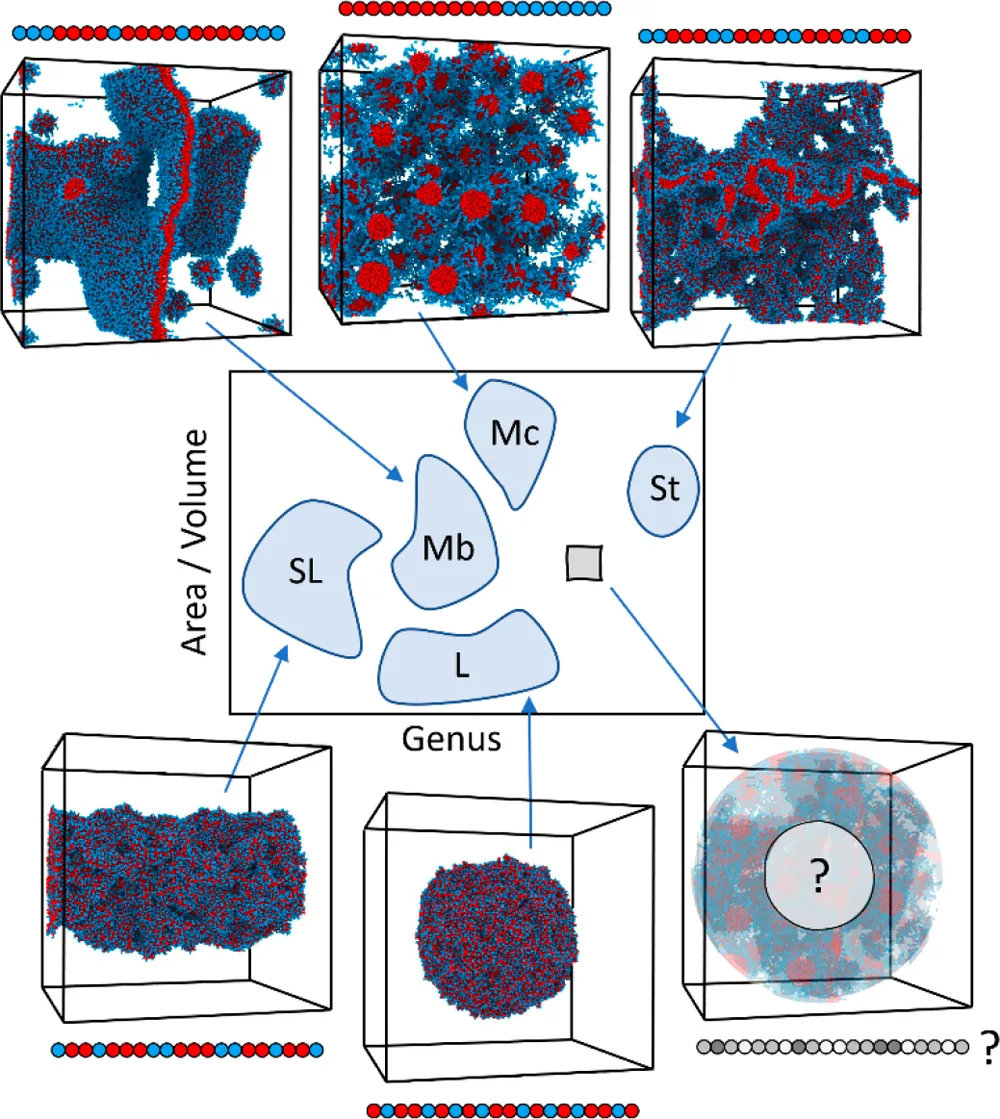

*Fig. 1: Reinhart & Statt, Acc. Mater. Res. **2**, 697-700 (2021). [doi.org/10.1021/accountsmr.1c00089](https://doi.org/10.1021/accountsmr.1c00089)*

Known sequences point to known morphology regions, and one region is left with a question mark: the sequence that would produce a chosen target structure.
Section 3 uses the group's 2024 evolutionary algorithm to search it. The 10-mer space is small
enough to check by enumeration.

In [ ]:
#@title  ⚙️  data_bootstrap — verify data/master64 & data/exhaustive10 artifacts are present. You can ignore this cell. { display-mode: "form" }
#
# A fresh checkout only ships the small derived tables in data/master64/ (tracked in git,
# see data/master64/README.md) -- the large binaries (pca.joblib, atlas*.png, _images/) and
# the full exhaustive10 library are regenerated or fetched separately and are NOT guaranteed
# to be present. Rather than let a missing file surface as a cryptic pandas/joblib traceback
# many cells later, this module checks up front and fails with an actionable message.
#
# This is deliberately a *data*-layer check, not a model one: models/gru_bundle.joblib has
# its own, stricter provenance binding (sha256 of pca.joblib + sequence_z_targets.csv recorded
# inside the bundle, checked at load time -- see notebook 06, "Provenance binding, not just a
# file-exists cache"). That check catches "this trained model doesn't match today's data" and
# is not duplicated here. This module only answers the earlier question: are the required data
# files even on disk, and do the git-tracked ones match what's checked in (data/master64/checksums.json)?

import hashlib
import json
import os
import shutil
import tarfile
import urllib.request


def sha256_of_file(path, chunk_size=1 << 20):
    """Hash a file's bytes. Same convention notebook 06 uses to bind gru_bundle.joblib
    to the pca.joblib / sequence_z_targets.csv it was trained against."""
    h = hashlib.sha256()
    with open(path, 'rb') as f:
        for chunk in iter(lambda: f.read(chunk_size), b''):
            h.update(chunk)
    return h.hexdigest()


def require_data_artifacts(base_dir, filenames, checksums_path=None, regen_hint=''):
    """Verify each of `filenames` exists under `base_dir`, and -- if `checksums_path` points
    at a JSON {filename: sha256} manifest that has an entry for it -- that its sha256 matches.

    Call this once, right after the relevant `*_DIR` is set, before any of `filenames` is
    read. Raises RuntimeError with every missing/mismatched file listed together (not just
    the first one hit) and a regeneration hint, instead of letting the notebook die on
    whichever read happens to come first.
    """
    checksums = {}
    if checksums_path and os.path.exists(checksums_path):
        with open(checksums_path) as f:
            checksums = json.load(f)

    missing, mismatched = [], []
    for name in filenames:
        path = os.path.join(base_dir, name)
        if not os.path.exists(path):
            missing.append(path)
            continue
        expected = checksums.get(name)
        if expected is not None:
            actual = sha256_of_file(path)
            if actual != expected:
                mismatched.append((path, expected, actual))

    if not missing and not mismatched:
        return

    parts = []
    if missing:
        listed = '\n  '.join(missing)
        parts.append(f'Missing required data artifact(s):\n  {listed}')
    if mismatched:
        listed = '\n  '.join(
            f'{p}\n    expected sha256 {exp[:12]}…, found {act[:12]}… '
            f'(local file does not match data/master64/checksums.json)'
            for p, exp, act in mismatched
        )
        parts.append(f'Data artifact(s) present but do NOT match the checked-in checksums:\n  {listed}')
    if regen_hint:
        parts.append(regen_hint)
    raise RuntimeError('\n\n'.join(parts))


# ── Bundle fetch shim (data/_bundles/*.tar.gz) ──────────────────────────────
#
# `data/_bundles/` holds gzip-tar archives packaging the subset of `data/` a
# fresh checkout doesn't ship (large binaries: images, GSDs, the exhaustive10
# library, and notebook 06's trained model artifacts). Each archive's relative
# paths match their layout under `data/`/`models/` exactly (e.g.
# `master64/pca.joblib`, `models/gru_predictor.pt`), so extracting one directly
# into `data_dir` reproduces the paths every notebook already expects -- no
# notebook-side path changes needed once a bundle is fetched. See
# `data/_bundles/manifest.json` for the authoritative sha256/size of every
# archive; this module's `ensure_bundle` reads that same file.
#
# Hosted on Zenodo, concept DOI 10.5281/zenodo.21382941, which always resolves to the
# latest version. ZENODO_RECORD above pins a specific version record on purpose, so a
# checkout keeps fetching the exact archives it was tested against: currently v2
# (record 21856114), which adds the random-walk-init arm to v1's (21382942) lattice-init
# data. Zenodo carries every prior version's files forward, so the v1 archive names keep
# resolving against the newer record.
# Wired up and live: within Day 3, notebooks 07, 08 and 09 each call
# `ensure_bundle('core')` followed by `reconcile_bundle_models()` before loading the
# trained GRU surrogate.
#
# Kept identical to day1/day2's copies of this shim (same URLs) -- duplicated
# per-day rather than cross-imported, matching this repo's existing convention
# of a self-contained data_bootstrap.py per day. Only the day-specific loaders and
# helpers differ between the three copies (`reconcile_bundle_models()` here,
# `fetch_gsd_for_sequence` in day1, the exhaustive10 .npz loaders in day2).

ZENODO_RECORD = 'https://zenodo.org/api/records/21856114/files'

BUNDLE_URLS = {
    'core': f'{ZENODO_RECORD}/core.tar.gz/content',
    'full_images': f'{ZENODO_RECORD}/full_images.tar.gz/content',
    'gsd_shard_01': f'{ZENODO_RECORD}/gsd_shard_01.tar.gz/content',
    'gsd_shard_02': f'{ZENODO_RECORD}/gsd_shard_02.tar.gz/content',
    'gsd_shard_03': f'{ZENODO_RECORD}/gsd_shard_03.tar.gz/content',
    'gsd_shard_04': f'{ZENODO_RECORD}/gsd_shard_04.tar.gz/content',
    'gsd_shard_05': f'{ZENODO_RECORD}/gsd_shard_05.tar.gz/content',
    'gsd_shard_06': f'{ZENODO_RECORD}/gsd_shard_06.tar.gz/content',
    'gsd_shard_07': f'{ZENODO_RECORD}/gsd_shard_07.tar.gz/content',
    'gsd_shard_08': f'{ZENODO_RECORD}/gsd_shard_08.tar.gz/content',
    'gsd_shard_09': f'{ZENODO_RECORD}/gsd_shard_09.tar.gz/content',
    'gsd_shard_10': f'{ZENODO_RECORD}/gsd_shard_10.tar.gz/content',
    'gsd_shard_11': f'{ZENODO_RECORD}/gsd_shard_11.tar.gz/content',
    'gsd_shard_12': f'{ZENODO_RECORD}/gsd_shard_12.tar.gz/content',
    'gsd_shard_13': f'{ZENODO_RECORD}/gsd_shard_13.tar.gz/content',
    'gsd_shard_14': f'{ZENODO_RECORD}/gsd_shard_14.tar.gz/content',
    'gsd_shard_15': f'{ZENODO_RECORD}/gsd_shard_15.tar.gz/content',
    'gsd_shard_16': f'{ZENODO_RECORD}/gsd_shard_16.tar.gz/content',
    'rwinit_core': f'{ZENODO_RECORD}/rwinit_core.tar.gz/content',
    'rwinit_gsd_shard_01': f'{ZENODO_RECORD}/rwinit_gsd_shard_01.tar.gz/content',
    'rwinit_gsd_shard_02': f'{ZENODO_RECORD}/rwinit_gsd_shard_02.tar.gz/content',
    'rwinit_gsd_shard_03': f'{ZENODO_RECORD}/rwinit_gsd_shard_03.tar.gz/content',
    'rwinit_gsd_shard_04': f'{ZENODO_RECORD}/rwinit_gsd_shard_04.tar.gz/content',
    'rwinit_gsd_shard_05': f'{ZENODO_RECORD}/rwinit_gsd_shard_05.tar.gz/content',
    'rwinit_gsd_shard_06': f'{ZENODO_RECORD}/rwinit_gsd_shard_06.tar.gz/content',
    'rwinit_gsd_shard_07': f'{ZENODO_RECORD}/rwinit_gsd_shard_07.tar.gz/content',
    'rwinit_gsd_shard_08': f'{ZENODO_RECORD}/rwinit_gsd_shard_08.tar.gz/content',
    'rwinit_gsd_shard_09': f'{ZENODO_RECORD}/rwinit_gsd_shard_09.tar.gz/content',
    'rwinit_gsd_shard_10': f'{ZENODO_RECORD}/rwinit_gsd_shard_10.tar.gz/content',
    'rwinit_gsd_shard_11': f'{ZENODO_RECORD}/rwinit_gsd_shard_11.tar.gz/content',
    'rwinit_gsd_shard_12': f'{ZENODO_RECORD}/rwinit_gsd_shard_12.tar.gz/content',
    'rwinit_gsd_shard_13': f'{ZENODO_RECORD}/rwinit_gsd_shard_13.tar.gz/content',
    'rwinit_gsd_shard_14': f'{ZENODO_RECORD}/rwinit_gsd_shard_14.tar.gz/content',
    'rwinit_gsd_shard_15': f'{ZENODO_RECORD}/rwinit_gsd_shard_15.tar.gz/content',
    'rwinit_gsd_shard_16': f'{ZENODO_RECORD}/rwinit_gsd_shard_16.tar.gz/content',
    'rwinit_images': f'{ZENODO_RECORD}/rwinit_images.tar.gz/content',
}


# Embedded copy of data/_bundles/manifest.json (sha256 + size only -- the two fields
# ensure_bundle verifies). The manifest normally ships in the repo, but a Colab student
# opens a bare .ipynb with no repo around it, so a repo-only manifest would make every
# ensure_bundle() call fail before it ever reached Zenodo. The on-disk file still wins
# when present (instructors regenerating bundles); this is the fallback.
EMBEDDED_MANIFEST = {
    "core.tar.gz": {
        "sha256": "aa8e566e323d83a3cf5bd9f8d66af97597176bfa556497536a2313d9257a86e8",
        "size_bytes": 75795762
    },
    "full_images.tar.gz": {
        "sha256": "f5a3be425507b54446b6b8b432432e612637a26105cacd94ba04f46f9fcd9f98",
        "size_bytes": 85260688
    },
    "gsd_shard_01.tar.gz": {
        "sha256": "5ffe93ba71d42eed5abeedcc6e4dd9e0bc8d160e3d2f134cea06285b9781d590",
        "size_bytes": 54428843
    },
    "gsd_shard_02.tar.gz": {
        "sha256": "541573a1d8176f89f4f838698bee261a24818c93967b0c969e8d295ba87805eb",
        "size_bytes": 54515060
    },
    "gsd_shard_03.tar.gz": {
        "sha256": "5fd7ed9efce62468b73e633b3dd56de13ca5d5e83c87222b5d0f30eab3cd874d",
        "size_bytes": 54500993
    },
    "gsd_shard_04.tar.gz": {
        "sha256": "7c2b102d648d918bb5f702137c925533c32c22070d5a20075b536f795251524c",
        "size_bytes": 54501617
    },
    "gsd_shard_05.tar.gz": {
        "sha256": "f8da9b7c5e515e5a61b6b91d390a65a95b85aab48a6b31c6a2f5bb786306e1ee",
        "size_bytes": 54486771
    },
    "gsd_shard_06.tar.gz": {
        "sha256": "40d94a51cf1c4e59e06998e438b40a67ee52f7447e4e8089e6c1ba3efe707e92",
        "size_bytes": 54503309
    },
    "gsd_shard_07.tar.gz": {
        "sha256": "3a1a633d093e8df54062868bca408b2ea81d3121b6e18e151fabd620c9908227",
        "size_bytes": 54545175
    },
    "gsd_shard_08.tar.gz": {
        "sha256": "6edd4e9b39081c82847da3e8f5c048ba07b774513514bb293d8fc43c5f59fe5c",
        "size_bytes": 54553660
    },
    "gsd_shard_09.tar.gz": {
        "sha256": "ddebef1f8420db4e1646013640450f06c50883cc8220e6fe47847dbc816bab48",
        "size_bytes": 54529750
    },
    "gsd_shard_10.tar.gz": {
        "sha256": "8f92a0c7261217e282f16370b1483ab72c7627d452369a302d4a1cb553fd2101",
        "size_bytes": 54576422
    },
    "gsd_shard_11.tar.gz": {
        "sha256": "b4f713683ce4c9a9c7338a973162c33e26fae4abd3198ce51a232d41ab7d8213",
        "size_bytes": 54614646
    },
    "gsd_shard_12.tar.gz": {
        "sha256": "c6d9199bb584dec3dab80518ce52e591d90dcbd55d4565a17bfd899cec1cde90",
        "size_bytes": 54558926
    },
    "gsd_shard_13.tar.gz": {
        "sha256": "e40332193347a5532fc560189608b46617fc277333be14ae6a1a73b4b619ea27",
        "size_bytes": 54515392
    },
    "gsd_shard_14.tar.gz": {
        "sha256": "cd88ff742f800ba576088cb680d0d61dd7c9c63090a77c25deeddf54d728f748",
        "size_bytes": 54556976
    },
    "gsd_shard_15.tar.gz": {
        "sha256": "d4eea2c8040774d777ac384b55c5a8e473e413619c8b799690121986dcce0c61",
        "size_bytes": 54553791
    },
    "gsd_shard_16.tar.gz": {
        "sha256": "403bf562e8325f34d4b04dff699d3cc35a9b4e7dda231e01a5fdb836a9b788d1",
        "size_bytes": 54546362
    },
    "rwinit_core.tar.gz": {
        "sha256": "11cf1dc26ee026894c3be5e845d3999c1f92d43db05b2cd6eeaae92d319f1d34",
        "size_bytes": 7205225
    },
    "rwinit_gsd_shard_01.tar.gz": {
        "sha256": "064e6bd3fa80355f869f0bc29709c9df7ee5957c23e75d0e1507f405de3f7b55",
        "size_bytes": 57106441
    },
    "rwinit_gsd_shard_02.tar.gz": {
        "sha256": "41797e4e0ca818f6f6cee27eef92eecd41fa4bd0bd9d005578feae96c91bb9ac",
        "size_bytes": 57129517
    },
    "rwinit_gsd_shard_03.tar.gz": {
        "sha256": "d78bcb538e3fce2e05cf2dc2a835fd38f05a4073865e67398bec873bfd9941a5",
        "size_bytes": 57072047
    },
    "rwinit_gsd_shard_04.tar.gz": {
        "sha256": "23c24f3dbc2df1d9cdaba442dc88c6beb4c023285ee058cbf4adcaeb8964e603",
        "size_bytes": 57081717
    },
    "rwinit_gsd_shard_05.tar.gz": {
        "sha256": "2dae4ba886506429b40f82896be904a756b3f4bbb0b817792cdd7fb64e54820f",
        "size_bytes": 57089702
    },
    "rwinit_gsd_shard_06.tar.gz": {
        "sha256": "cf175506cbce294a5204abf811db5ca5f74c21d90af1516a30d08e6c188b53e3",
        "size_bytes": 57098922
    },
    "rwinit_gsd_shard_07.tar.gz": {
        "sha256": "d19cab8e719aa1fe4167a7982c3fa9f8acadb776711eb4aa2dba2840fcdd27d0",
        "size_bytes": 57116603
    },
    "rwinit_gsd_shard_08.tar.gz": {
        "sha256": "55ac119a7e3159659151abe48811389568030095af779b9adcbd5d2039f7897a",
        "size_bytes": 57066241
    },
    "rwinit_gsd_shard_09.tar.gz": {
        "sha256": "750a92ae6bf8fe2cf9fe84614c980f03ea9a216253a4e3fd501d8879ec69fad7",
        "size_bytes": 57096549
    },
    "rwinit_gsd_shard_10.tar.gz": {
        "sha256": "4bb7b54dde96fb561b9ed961882a4310f6de42536cd80d4f7060cef604b116e7",
        "size_bytes": 57082391
    },
    "rwinit_gsd_shard_11.tar.gz": {
        "sha256": "8c284243824ca2b8630b306ea5d44c9fe64c63638a361b6c7e60d4894d156264",
        "size_bytes": 57056742
    },
    "rwinit_gsd_shard_12.tar.gz": {
        "sha256": "251b86d2a278b5f10bbb192dc4c0deb6f965cb9ab47068a9520cf6bcb88a8035",
        "size_bytes": 57070629
    },
    "rwinit_gsd_shard_13.tar.gz": {
        "sha256": "e6e2d6771e8692774e71cf888d189d8c67b511e42b76434d13bf6088f88e4467",
        "size_bytes": 57086857
    },
    "rwinit_gsd_shard_14.tar.gz": {
        "sha256": "08285cd063243b96d05449b80356f83e16fd50c2a5b9913f59f6204d72423479",
        "size_bytes": 57101498
    },
    "rwinit_gsd_shard_15.tar.gz": {
        "sha256": "b700f555dbf7f59bc46bb6f41a6745a7397c5094a52a53f1b46969ab333a27ea",
        "size_bytes": 57105780
    },
    "rwinit_gsd_shard_16.tar.gz": {
        "sha256": "1a0a6519f41984aead7405bc927e1159d02f9adff42b8076a52846e174a20542",
        "size_bytes": 57058599
    },
    "rwinit_images.tar.gz": {
        "sha256": "88919f2fcc542f6681fd65f82c80c40f346ef5b911089d09496d58a817ad247d",
        "size_bytes": 290556878
    },
}


def ensure_bundle(name, data_dir=None, manifest_path=None):
    """Download-if-absent + sha256-verify + extract a named bundle archive into `data_dir`.

    `name` is a key of `BUNDLE_URLS` (e.g. `'core'`, `'gsd_shard_03'`). Idempotent: if
    `data_dir/_bundles/<name>.tar.gz` already exists on disk AND matches the sha256
    recorded in the manifest, it is reused rather than re-downloaded; the archive is
    always re-verified against the manifest before extraction, so a corrupt or partial
    local copy is caught rather than silently extracted.

    `data_dir` defaults to `'../data'`, matching the relative path every notebook in
    this repo already uses for `MASTER_DIR`/`EXHAUSTIVE_DIR`/`GSD_DIR`. `manifest_path`
    defaults to `<data_dir>/_bundles/manifest.json`.
    """
    if data_dir is None:
        data_dir = '../data'
    if manifest_path is None:
        manifest_path = os.path.join(data_dir, '_bundles', 'manifest.json')

    if name not in BUNDLE_URLS:
        raise RuntimeError(
            f"Unknown bundle {name!r}. Known bundles: {sorted(BUNDLE_URLS)}."
        )
    url = BUNDLE_URLS[name]
    if url is None:
        raise RuntimeError(
            f"Bundle {name!r} is not hosted yet (BUNDLE_URLS[{name!r}] is None in "
            f"data_bootstrap.py). Fill in its URL once hosting exists. Until then, "
            f"the data this bundle would provide (see its 'contents_summary' in "
            f"data/_bundles/manifest.json) must already be present on disk for any "
            f"notebook that needs it."
        )

    if os.path.exists(manifest_path):
        with open(manifest_path) as f:
            manifest = json.load(f)
    else:
        manifest = EMBEDDED_MANIFEST

    archive_filename = f'{name}.tar.gz'
    if archive_filename not in manifest:
        raise RuntimeError(
            f"{archive_filename!r} has no entry in {manifest_path}. Known archives: "
            f"{sorted(manifest)}."
        )
    entry = manifest[archive_filename]
    expected_sha256 = entry['sha256']
    expected_size = entry['size_bytes']

    bundles_dir = os.path.join(data_dir, '_bundles')
    os.makedirs(bundles_dir, exist_ok=True)
    archive_path = os.path.join(bundles_dir, archive_filename)

    def _verified():
        return (
            os.path.exists(archive_path)
            and os.path.getsize(archive_path) == expected_size
            and sha256_of_file(archive_path) == expected_sha256
        )

    if not _verified():
        print(f'Downloading {archive_filename} from {url} ...')
        urllib.request.urlretrieve(url, archive_path)
        if not _verified():
            raise RuntimeError(
                f"Downloaded {archive_path} does not match the manifest (expected "
                f"sha256 {expected_sha256[:12]}..., size {expected_size} bytes). The "
                f"download may be corrupt or the hosted file may not match "
                f"{manifest_path} -- delete {archive_path} and retry, or re-check the "
                f"manifest."
            )

    print(f'Extracting {archive_filename} into {data_dir} ...')
    with tarfile.open(archive_path, 'r:gz') as tf:
        tf.extractall(data_dir, filter='data')
    print(f'{name!r} bundle ready under {data_dir}.')


def reconcile_bundle_models(data_dir=None, models_dir=None):
    """`core.tar.gz` packages notebook 06's trained-model artifacts under a top-level
    `models/` entry -- rooted at the repo root, a SIBLING of `data/` -- alongside its
    data/-rooted entries (`master64/`, `exhaustive10/`, ...). `ensure_bundle` extracts
    the whole archive into one `data_dir`, which is correct for the data/-rooted
    entries but leaves `models/` nested one level too deep, at `data_dir/models/`
    instead of `models_dir`. There's no single extraction root that places both
    correctly, so call this right after `ensure_bundle('core')` to move anything it
    left at `data_dir/models/` up to `models_dir` (a no-op if nothing needs moving).
    """
    if data_dir is None:
        data_dir = '../data'
    if models_dir is None:
        models_dir = '../models'
    stray = os.path.join(data_dir, 'models')
    if not os.path.isdir(stray):
        return
    os.makedirs(models_dir, exist_ok=True)
    for name in os.listdir(stray):
        src = os.path.join(stray, name)
        dst = os.path.join(models_dir, name)
        if not os.path.exists(dst):
            shutil.move(src, dst)

In [ ]:
# Fetch the derived tables and trained-model artifacts up front. Cells below read them
# directly, and on Colab nothing is on disk until this runs. Idempotent: later
# ensure_bundle('core') calls re-verify the cached archive instead of re-downloading.
ensure_bundle('core')
reconcile_bundle_models()   # core packages models/ one level deep under data/
print('data and model artifacts verified')

In [ ]:
# All dependencies pre-installed on Colab
import os

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

# 1. The inverse problem, and where brute force dies

## Forward vs. inverse

The forward map is the surrogate we trained in 06: $f(s) = \hat{z} \in \mathbb{R}^2$, a sequence in and its predicted latent coordinates out ($s$ a sequence string, $\hat{z}$ is `predict_fn(s)`).
Inverse design finds a sequence $s^\ast$ such that $f(s^\ast) \approx z^\ast$ for a chosen target $z^\ast$.
The forward direction is a single cheap function call; the inverse direction is a search.



The loop proposes, scores, and retains candidates. Sections 2 and 3 define the score and search.

## Notation

Workshop notation from notebook 01:

* a **sequence** $s \in \{A, B\}^{10}$, encoded with monomer $A = $ `0` and $B = $ `1`
* a **fingerprint** $x \in \mathbb{R}^{1280}$ (the CNN features from 03)
* a **latent** structure coordinate $z \in \mathbb{R}^2$ (the PCA map from 04/05, columns `z0`, `z1`)
* the **surrogate** $f: s \to \hat{z}$ (the GRU, `model`/`predict_fn`)
* the **oracle**, meaning MD plus featurization, the ground truth $f$ is trained to imitate

The GRU takes the scalar `(n, L, 1)` encoding from 06 (one channel, $A=0$, $B=1$), not a one-hot encoding.

## The catch: the inverse is ill-posed

$f$ is **many-to-one**: different sequences can assemble into the same morphology. The preimage
$f^{-1}(z^\ast)$ is a set and may be empty, so direct inversion is ill-posed.

A direct inverse network must select among several valid sequences, and its output still requires
validation. Optimization only needs one sequence whose prediction is close to $z^\ast$.

In [ ]:
# The real design map is many-to-one. Show it on the actual data, not a toy: take the 528
# reversal-canonical (sequence -> z) pairs (64 from the master64 campaign that trained the PCA,
# plus 464 projected through that embedding), bin z into a coarse grid at roughly the
# replica-noise scale, and count how many DISTINCT sequences land in each occupied cell. That
# count is the size of the real 'fiber'.
_zt = pd.read_csv('../data/master64/sequence_z_targets.csv')
_zt['Sequence'] = _zt['Sequence'].astype(str).str.zfill(10)
_nb = 10
def _binned(col):
    lo, hi = _zt[col].min(), _zt[col].max()
    return np.floor((_zt[col] - lo) / ((hi - lo) / _nb)).clip(0, _nb - 1).astype(int)
_zt['cell'] = list(zip(_binned('z0'), _binned('z1')))
_fiber = _zt.groupby('cell').size()
print(f'sequences={len(_zt)}, occupied cells={_fiber.size}/{_nb * _nb}, '
      f'max cell count={_fiber.max()}, median cell count={int(_fiber.median())}')
print(f'{_fiber.size} of the {_nb * _nb} possible z-cells are occupied')

In [ ]:
fig, ax = plt.subplots(figsize=(6, 3.6))
ax.hist(_fiber.values, bins=range(1, _fiber.max() + 2), color='steelblue', edgecolor='k', align='left')
ax.set_xlabel('distinct sequences sharing one z-cell (fiber size)')
ax.set_ylabel('number of z-cells')
plt.tight_layout()
plt.show()

In [ ]:
# Concretely: two sequences that could hardly be more different, yet the map sends them to one cell.
_grp = _zt.groupby('cell')['Sequence'].apply(list)
def _ham(a, b): return sum(x != y for x, y in zip(a, b))
_best = max(((_ham(a, b), a, b) for seqs in _grp for i, a in enumerate(seqs) for b in seqs[i + 1:]),
           key=lambda t: t[0])
print(f'max within-cell Hamming distance={_best[0]}: {_best[1]} vs {_best[2]}')

That is the inverse map's degeneracy made concrete, on real data: the busiest z-cell holds **30 distinct length-10 sequences**, and two of them (`0000101110`, `0111010001`) differ at 9 of 10 positions yet land in the same cell.
This differs from 03's scalar descriptor degeneracy. Here, the map $f: s \to z$ is many-to-one.

## The high-throughput-screening bottleneck

The design space is $\{A, B\}^L$, size $2^L$. At $L = 10$ that is 1,024 sequences, small enough to screen exhaustively with MD (Days 1-2), but it grows exponentially: $L = 30$ gives $2^{30} \approx 1.07 \times 10^9$.
**High-throughput screening (HTS)** pays the oracle cost $2^L$ times. This becomes infeasible at realistic polymer lengths.

In [ ]:
lengths = np.arange(5,51)
counts = 2.0 ** lengths
fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(lengths, counts, marker='o', ms=3, color='steelblue')
ax.axvline(10, color='green', linestyle='--', label='L=10 (brute-force feasible, this notebook)')
ax.axvline(30, color='red', linestyle='--', label='L=30 (brute-force infeasible)')
ax.set_xlabel('Chain length L')
ax.set_ylabel('Sequences to screen (log scale)')
ax.legend()
plt.tight_layout()
plt.show()

The log-scale plot shows exponential growth. An optimizer can propose candidates without evaluating the full space.

## [Check your understanding] Combinatorics

* **Predict first:** at an optimistic $10^5$ sequences/second, how long is a full $L = 20$
  brute-force scan? Guess before you compute.
* Compute `2**20 / 1e5 / 60` minutes and compare to your guess.
* By what factor does each additional $+10$ in $L$ multiply that time?

> $2^{20} \approx 1.05\text{M}$, so about $0.17$ minutes. Each $+10$ in $L$ multiplies the time
> by about 1000x ($2^{10} = 1024$).

# 2. Designing the fitness function

## A cheap score from the surrogate

Candidate fitness measures the distance between predicted structure and the target morphology.
We reuse the GRU from 06 (`GRUPredictor`) as a **surrogate oracle**: $\hat{z} = f(s)$ in a fraction of a millisecond instead of a full MD run.

**Fitness** is the negative Euclidean distance from the prediction to the target: $\text{fit}(s) = -\lVert \bar f(s) - z^\ast \rVert_2$.
Mapping symbols to code, $\bar f(s)$ is `predict_z_sym(seqs)`, $z^\ast$ is `target_z`, and `fitness(...)` returns the score.
It is negative by construction, so higher (closer to 0) is better: an exact hit scores 0.

$\bar f$ averages the GRU over both string orientations: $\bar f(s) = \tfrac12[f(s) + f(\text{reverse}(s))]$.
Every objective in this notebook (enumeration, EA, brute-force) is built on this one symmetric prediction $\bar f$.

`fitness(...)` above (plain, signed distance) is a teaching scalar for the composition-penalty demo below.
The actual objective is `design_score(seqs, target_z)`: negative squared symmetric distance $-\lVert\bar f(s) - z^\ast\rVert_2^2$.
Squared vs plain distance are monotonically equivalent, so rankings are identical.

This is the GRU class from notebook 06. The trained weights are loaded below.

In [ ]:
def encode_sequences(seqs):
    """Encode binary strings to (n, L, 1) float array; L inferred from seqs[0]."""
    L = len(seqs[0])
    if any(len(s) != L for s in seqs):
        raise ValueError("all sequences must share one length")
    flat = np.array([[int(c) for c in s] for s in seqs], dtype=np.float32)
    return flat.reshape(len(seqs), L, 1)


class GRUPredictor(torch.nn.Module):
    def __init__(self, hidden_dim=64, n_layers=2, dropout=0.1):
        super().__init__()
        self.gru = torch.nn.GRU(input_size=1, hidden_size=hidden_dim, num_layers=n_layers,
                                 batch_first=True, bidirectional=True,
                                 dropout=dropout if n_layers > 1 else 0.0)
        self.head = torch.nn.Linear(2 * hidden_dim, 2)

    def forward(self, x):
        _, hn = self.gru(x)
        h = torch.cat([hn[-2], hn[-1]], dim=1)
        return self.head(h)

## Loading the pre-trained surrogate

Load the weights and Z-coordinate scaler saved by notebook 06. Missing artifacts raise an error.

In [ ]:
MODELS_DIR    = '../models'
MODEL_WEIGHTS = os.path.join(MODELS_DIR, 'gru_predictor.pt')
SCALER_PATH   = os.path.join(MODELS_DIR, 'gru_z_scaler.joblib')
MASTER_DIR    = os.environ.get('CDSE_DATA_DIR', '../data/master64')

require_data_artifacts(
    MASTER_DIR,
    ['pca_coords.csv', 'sequence_z_targets.csv', 'pca.joblib'],
    checksums_path=os.path.join(MASTER_DIR, 'checksums.json'),
    regen_hint=(
        'See data/master64/README.md and campaign/build_master64.py to regenerate, or pull '
        'the latest data/master64/ from git.'
    ),
)

# gru_predictor.pt / gru_z_scaler.joblib are notebook 06's trained-and-persisted artifacts,
# gitignored (like all trained weights) but shipped in the `core` Zenodo bundle so this
# notebook can load them standalone without re-running 06's training.
ensure_bundle('core')
reconcile_bundle_models()  # core.tar.gz packages models/ nested one level too deep
print(f'looking for GRU weights at {MODEL_WEIGHTS}')

In [ ]:
if not os.path.exists(MODEL_WEIGHTS):
    raise FileNotFoundError(
        f'{MODEL_WEIGHTS} not found. ensure_bundle(\'core\') should have fetched it; check '
        'the bundle manifest, or run notebook 06 to train and persist these weights yourself.'
    )
if not os.path.exists(SCALER_PATH):
    raise FileNotFoundError(
        f'{SCALER_PATH} not found. ensure_bundle(\'core\') should have fetched it; check '
        'the bundle manifest, or run notebook 06 to fit and persist the Z-coordinate '
        'StandardScaler yourself.'
    )
print(f'found {MODEL_WEIGHTS} and {SCALER_PATH}')

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = GRUPredictor(hidden_dim=64, n_layers=2, dropout=0.1).to(device)
model.load_state_dict(torch.load(MODEL_WEIGHTS, map_location=device))
print(f'Loaded pre-trained GRU weights from {MODEL_WEIGHTS} (saved by notebook 06).')

In [ ]:
scaler = joblib.load(SCALER_PATH)
print(f'Loaded the train-fit Z-coordinate scaler from {SCALER_PATH}.')

In [ ]:
def predict_fn(seqs):
    """Wrap the trained GRU: predict_fn(list[str]) -> (n, 2) array of Z coordinates.

    Encodes each sequence, runs it through the GRU, and inverse-transforms the standardized
    output back into the deployed N=64-fit PCA units (columns `z0`, `z1` everywhere in 04-09).
    """
    X = encode_sequences(seqs)
    X_t = torch.tensor(X, dtype=torch.float32).to(device)
    model.eval()
    with torch.no_grad():
        z_scaled = model(X_t).cpu().numpy()
    return scaler.inverse_transform(z_scaled)


# SHARED, reversal-symmetric prediction (the keystone objective helper): the GRU is NOT
# reversal-invariant, so we average both orientations, z_bar(s) = 1/2[f(s) + f(reverse(s))],
# reversal-invariant by construction. Every objective in this notebook is built on `predict_z_sym`.
def predict_z_sym(seqs):
    """Reversal-symmetric Z: average the GRU over both string orientations of each polymer."""
    seqs = list(seqs)
    z_fwd = np.asarray(predict_fn(seqs), dtype=float)
    z_rev = np.asarray(predict_fn([s[::-1] for s in seqs]), dtype=float)
    return 0.5 * (z_fwd + z_rev)

In [ ]:
def design_score(seqs, target_z):
    """THE single Day-3 keystone objective (higher is better): negative SQUARED
    reversal-symmetric predicted distance to target. We optimize/rank by this and
    report its square-root (the distance) against d*."""
    z = predict_z_sym(list(seqs))
    d2 = np.sum((z - np.asarray(target_z, dtype=float)) ** 2, axis=1)
    return -d2

In [ ]:
def fitness(seqs, target_z, predict_fn=None):
    """Negative Euclidean distance from the reversal-symmetric predicted Z to target_z, higher
    is better. Uses `predict_z_sym` (both orientations averaged), so `fitness(s) == fitness(rev(s))`
    exactly. `predict_fn` is accepted for backward-compatible call sites but ignored: the symmetric
    prediction is always used, since a physical polymer has no preferred string orientation."""
    z = predict_z_sym(list(seqs))
    return -np.linalg.norm(z - np.asarray(target_z, dtype=float), axis=1)

## Averaging both orientations

Measure the GRU prediction difference between a sequence and its reverse.

In [ ]:
_probe = ['1000100111', '0110001011', '0101010101', '0000011111', '0110000011']
_zf = predict_fn(_probe)
_zr = predict_fn([s[::-1] for s in _probe])
_gap = np.linalg.norm(_zf - _zr, axis=1)
print("Raw GRU disagreement between a sequence and its string-reverse (same physical polymer):")
for s, g in zip(_probe, _gap):
    print(f"  {s} vs {s[::-1]}:  |f(s) - f(reverse(s))| = {g:.3f} Z-units")
print(f'reversal disagreement across this probe: mean {_gap.mean():.3f}, max {_gap.max():.3f} Z-units')

## Choosing a real, reachable-but-difficult target

We pin `target_z` to the actual PCA coordinates of a real, held-out sequence, `1000100111`, so the target is a genuine design question: a real molecule really does sit there, and it is **not** one of the 368 sequences the surrogate was trained on.

<details><summary><b>Target reachability and difficulty</b> (click to expand)</summary>

The 528 canonical sequences cover this region densely, and a training sequence lies nearby.
Section 5 shows that the surrogate can still be inaccurate in a well-sampled region.

**A note on data frames: one consistent convention.**
All of 04-09 live in a **single** PCA realization: `data/master64/sequence_z_targets.csv` (the 528-row table `predict_fn` and every distance below read from) and the deployed atlas map `data/master64/pca_coords.csv` are the same frame, both regenerated from the same seed-1 PCA fit (`pca.joblib`).
The two tables agree to floating-point precision on their shared sequences.
There is no frame offset to reconcile.

</details>

In [ ]:
targets_df = pd.read_csv(os.path.join(MASTER_DIR, 'sequence_z_targets.csv'), dtype={'Sequence': str})
seqs528    = targets_df['Sequence'].values
z_true528  = targets_df[['z0', 'z1']].values.astype(float)

target_seq = '1000100111'   # a real, GRU-held-out (val-split) polymer in DENSE L=10 coverage
target_z = targets_df.loc[targets_df['Sequence'] == target_seq, ['z0', 'z1']].values[0].astype(float)

print(f'target_seq = {target_seq}')
print(f'target_z   = ({target_z[0]:+.3f}, {target_z[1]:+.3f})  (its own real, measured Z-coordinate)')

Compare design scores for an alternating sequence and a diblock with the same composition.

In [ ]:
print('Sample design_score check:',
      design_score(['0101010101', '0000011111'], target_z))

The different scores show that the surrogate uses sequence order, not only composition.

**Reachability check.** Check that `target_z` is real and near the surrogate's training coverage.

<details><summary><b>Reachability check, in full</b> (click to expand)</summary>

**(a) Target existence.** `target_z` is the measured coordinate of `1000100111`, so its distance
to the closest simulated point is zero.

**(b) Training coverage.** `target_seq` is in the validation split, but a training point lies nearby.
The next cell reports the target sequence's prediction error.

</details>

In [ ]:
split_df   = pd.read_csv(os.path.join(MODELS_DIR, 'gru_split.csv'), dtype={'Sequence': str})
train_seqs = set(split_df.loc[split_df['split'] == 'train', 'Sequence'])
is_train528 = np.array([s in train_seqs for s in seqs528])
dist_to_train = np.linalg.norm(z_true528[is_train528] - target_z, axis=1)
d_nn_train = dist_to_train.min()
nn_train_seq = seqs528[is_train528][np.argmin(dist_to_train)]
print(f'{is_train528.sum()} of 528 sequences are in the GRU training split '
      f'(separate from the 64-sequence PCA training set); '
      f'nearest to target_z is {nn_train_seq} (distance {d_nn_train:.3f})')

In [ ]:
pred_target_z = predict_z_sym([target_seq])[0]
self_pred_err = np.linalg.norm(pred_target_z - target_z)
print(f'GRU self-prediction error for target_seq: {self_pred_err:.3f} Z-units')

In [ ]:
dist_true528 = np.linalg.norm(z_true528 - target_z, axis=1)
k_true = int(np.argmin(dist_true528))
print(f'closest real point at distance {dist_true528[k_true]:.3f}, nearest training point at {d_nn_train:.3f}')

## Calibrating "close" against our own measured noise floor

We define $d^\ast = 2\times$ the **local median single-replica RMSD-to-centroid** ($\sigma_\text{rep} = 0.432$), a literature-style convention (Reinhart & Statt 2024 apply the same "$2\times$ a noise floor" recipe, on a foreign value), not a calibrated $2\sigma$ confidence radius.

<details><summary><b>How d* is derived, and what it does and doesn't cover</b> (click to expand)</summary>

`campaign/measure_replica_noise.py` rendered and featurized 3 independent MD replicas of all 528 canonical sequences through the exact deployed pipeline, recording two things per sequence (`data/master64/replica_noise.csv`): **`rmsd_centroid`** (the RMS distance of that sequence's 3 replicas from their own centroid) and **`mean_pairwise`** (the mean of the 3 pairwise distances between those replicas).

Both are real spread measurements in this exact $Z$-space, but they answer different questions, and $d^\ast$ is built from only one of them.
$d^\ast = 2\,\sigma_\text{rep} = 0.864$ covers about 93% of the 528 per-sequence RMS-to-centroid radii, but only about 65% of actual same-sequence replica-pair distances (median pair distance $\approx 0.649$): two independent replicas can each sit up to $\sigma_\text{rep}$ from the centroid in different directions, so their mutual distance is typically larger than either one's distance to the centroid.

So read $d^\ast$ as a conventional screening radius, anchored to a real local measurement instead of an imported one, not as a guarantee that a design scoring inside it would be indistinguishable from the target under repeated MD.

</details>

In [ ]:
_rep = pd.read_csv(os.path.join(MASTER_DIR, 'replica_noise.csv'))
SIGMA_REP = float(np.median(_rep['rmsd_centroid']))         # local Z-space replica noise floor (median)
D_STAR = 2 * SIGMA_REP

# Two different real spread statistics, so d*'s coverage claim is measured, not asserted.
_z1 = _rep[['z0_seed1', 'z1_seed1']].values
_z2 = _rep[['z0_seed2', 'z1_seed2']].values
_z3 = _rep[['z0_seed3', 'z1_seed3']].values
_pair_dists = np.concatenate([
    np.linalg.norm(_z1 - _z2, axis=1),
    np.linalg.norm(_z1 - _z3, axis=1),
    np.linalg.norm(_z2 - _z3, axis=1),
])
_frac_centroid_covered = float(np.mean(_rep['rmsd_centroid'] <= D_STAR))
_frac_pair_covered = float(np.mean(_pair_dists <= D_STAR))
print(f"Local replica noise floor sigma_rep = median replica-to-centroid RMSD = {SIGMA_REP:.3f} "
      f"Z-units (n={len(_rep)} sequences x 3 seeds; data/master64/replica_noise.csv)")
print(f"d* = 2 x sigma_rep = {D_STAR:.3f}")
print(f"  covers {_frac_centroid_covered:.0%} of the {len(_rep)} per-sequence RMS-to-centroid "
      "radii")
print(f"  covers only {_frac_pair_covered:.0%} of same-sequence replica-PAIR distances "
      f"(n={len(_pair_dists)}; median pair distance = {np.median(_pair_dists):.3f})")
print(f'sigma_rep = {SIGMA_REP:.3f}, d* = {D_STAR:.3f} Z-units')

Plot replica coordinates for a typical sequence and an outlier.

In [ ]:
_q45, _q55, _q95 = _rep['rmsd_centroid'].quantile([0.45, 0.55, 0.95])
_typical_row = _rep[(_rep['rmsd_centroid'] >= _q45) & (_rep['rmsd_centroid'] <= _q55)].iloc[0]
_outlier_row = _rep[_rep['rmsd_centroid'] >= _q95].sort_values('rmsd_centroid').iloc[0]
print(f'typical: {_typical_row["sequence"]:010.0f} (rmsd={_typical_row["rmsd_centroid"]:.3f});  outlier: {_outlier_row["sequence"]} (rmsd={_outlier_row["rmsd_centroid"]:.3f})')

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, row, tag in zip(axes, [_typical_row, _outlier_row], ['typical', 'outlier']):
    zs = np.array([[row['z0_seed1'], row['z1_seed1']],
                   [row['z0_seed2'], row['z1_seed2']],
                   [row['z0_seed3'], row['z1_seed3']]])
    centroid = zs.mean(axis=0)
    ax.scatter(*zs.T, s=80, color='steelblue', zorder=3, label='3 real seed replicas')
    for i, (zx, zy) in enumerate(zs, start=1):
        ax.annotate(f'seed{i}', (zx, zy), textcoords='offset points', xytext=(6, 6), fontsize=8)
    ax.scatter(*centroid, marker='x', s=90, color='black', zorder=4, label='centroid')
    circ = plt.Circle(centroid, D_STAR, fill=False, linestyle='--', color='crimson', label='D*')
    ax.add_patch(circ)
    ax.set_aspect('equal')
    ax.set_title(f"{tag}: {row['sequence']:010.0f}  (rmsd_centroid={row['rmsd_centroid']:.3f})", fontsize=9)
    ax.set_xlabel('z0'); ax.set_ylabel('z1')
    ax.legend(fontsize=7, loc='best')
plt.tight_layout()
plt.show()

The outlier replica spread exceeds the screening radius. $D^\ast$ is a convention, not a guarantee.
(The deployed lookup coordinate every cell calls "$z$" is the **seed-1** replica, matching the `seed1` point plotted above.)

## Visualizing the fitness landscape

Plot `design_score`, the negative squared distance to the target, over $Z$.

The surrogate maps sequences directly to the validated 2-D $Z$ space. Distance is easier to
interpret here than in the 1280-D fingerprint space.

In [ ]:
# The keystone design_score landscape *in Z* is pure geometry: -||z - target_z||^2 on a grid. No
# GRU needed. (This is the actual objective optimized later, not a monotonic stand-in for it.)
g0 = np.linspace(target_z[0] - 4, target_z[0] + 4, 120)
g1 = np.linspace(target_z[1] - 4, target_z[1] + 4, 120)
ZX, ZY = np.meshgrid(g0, g1)
land = -((ZX - target_z[0]) ** 2 + (ZY - target_z[1]) ** 2)
print(f"Landscape ranges {land.min():.2f}..{land.max():.2f}; target_z = {target_z.tolist()}")

In [ ]:
# A handful of REAL sequences' GRU predictions, to scatter on the landscape (not fabricated points).
illustrative_seqs = ['0101010101', '0000011111', '0000000000', '1111111111', target_seq, nn_train_seq]
illustrative_z = predict_z_sym(illustrative_seqs)
print(f'scoring {len(illustrative_seqs)} illustrative sequences on the landscape')

In [ ]:
fig, ax = plt.subplots(figsize=(5.6, 4.6))
cf = ax.contourf(ZX, ZY, land, levels=18, cmap='viridis')
cb = plt.colorbar(cf, ax=ax); cb.set_label(r'design\_score  $-\|z-z^*\|_2^2$')
ax.plot(*target_z, marker='*', ms=22, color='gold', mec='k', mew=1.2, label=r'target $z^*$')
ax.scatter(illustrative_z[:, 0], illustrative_z[:, 1], s=48, color='white', edgecolor='k',
           zorder=5, label=r'predicted $f(s)$, real sequences')
ax.set_xlabel('$z_0$'); ax.set_ylabel('$z_1$')
ax.legend(loc='upper right', fontsize=8)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

Show the corresponding structures for these six predicted points.

In [ ]:
_ex_dir_07 = '../data/exhaustive10'
if os.path.isdir(_ex_dir_07):
    fig, axes = plt.subplots(1, len(illustrative_seqs), figsize=(3 * len(illustrative_seqs), 3.2))
    for ax, s in zip(axes, illustrative_seqs):
        img_path = f'{_ex_dir_07}/_images/{s}/all_xz_cv2_kde_sigma_2.0_size_224.webp'
        if os.path.exists(img_path):
            ax.imshow(plt.imread(img_path), cmap='gray')
        label = 'target_seq' if s == target_seq else ('nn_train_seq' if s == nn_train_seq else s)
        ax.set_title(f'{s}\n({label})', fontsize=7)
        ax.set_xticks([]); ax.set_yticks([])
    plt.tight_layout()
    plt.show()
else:
    print(f'({_ex_dir_07} not present locally; skipping the illustrative_seqs render panel.)')

In $Z$, the score has one maximum at $z^\ast$. Its mapping back to discrete sequence space is
rugged and contains plateaus.

But we don't have to search blind. At $L=10$ there are only 1,024 sequences (528 reversal-canonical ones), so we can just evaluate every single one.

## Exact enumeration at $L=10$

Score all 528 reversal-canonical sequences to obtain the exact surrogate optimum at $L=10$.

**Selection practice: top-5, not top-1.** Bhattacharya et al. 2022 screened all 63,090 sequences at their chain length and kept the 5 candidates nearest in $Z$-space per target, not the single closest, because a fast surrogate over a huge space always turns up several near-indistinguishable candidates. We follow that practice here: `top5_idx` below is the object we treat as "the enumeration's answer," not just its first entry.

In [ ]:
z_pred528  = predict_z_sym(list(seqs528))
score_pred528 = design_score(seqs528, target_z)               # THE keystone objective, called directly
dist_pred528 = np.linalg.norm(z_pred528 - target_z, axis=1)   # kept only for human-readable reporting
# Rank by descending design_score (higher = better); ascending plain distance gives the identical
# order since squaring is monotone, but we sort by the actual shared design_score here rather than
# relying on that equivalence.
order528 = np.argsort(score_pred528)[::-1]
top5_idx  = order528[:5]                      # Bhattacharya et al. 2022's HTS selection: top-5, not top-1
print(f'ranked {len(seqs528)} candidates; top-5 nearest to target_z selected')

In [ ]:
print(f'Enumerated all {len(seqs528)} canonical length-10 sequences in one batched GRU call.')
print(f"\n{'Rank':<5}{'Sequence':<14}{'pred dist':>10}{'true dist':>10}")
for rank, idx in enumerate(order528[:8], start=1):
    marker = '  <- top-5' if rank <= 5 else ''
    print(f"{rank:<5}{seqs528[idx]:<14}{dist_pred528[idx]:10.3f}{dist_true528[idx]:10.3f}{marker}")

In [ ]:
best_idx = int(order528[0])
print(f"\nExact optimum (by the surrogate): {seqs528[best_idx]}, "
      f"predicted distance {dist_pred528[best_idx]:.3f} to target.")
print(f"Top-5 selection (Bhattacharya et al. 2022 practice): {list(seqs528[top5_idx])}")

# Do these near-tied top candidates actually CLUSTER in z (degeneracy), or are they merely spread
# around a ring at the same radius from target_z (which would just be iso-fitness, not degeneracy)?
top8_z = z_pred528[order528[:8]]
top8_pairwise = np.linalg.norm(top8_z[:, None, :] - top8_z[None, :, :], axis=-1)
print(f"\nTop-8 predicted z's: max pairwise separation = {top8_pairwise.max():.3f} "
      f"(vs. their ~{dist_pred528[order528[:8]].mean():.2f} distance to target): "
      "clustered, not ring-spread.")
print(f'exact optimum by enumeration: {seqs528[best_idx]}')

Several sequences have similar predicted distances and form a cluster in $Z$. Bhattacharya et al.
(2022) therefore validate five candidates per target.
**Second, the `true dist` column** (the real, simulated distance, no GRU involved): the best-predicted candidate is not reliably the best-true candidate.
The predicted and true rankings differ. Section 5 measures this selection effect.

## The winner, and the handoff to notebook 08

The enumeration above **is** the exact answer at $L=10$: `seqs528[best_idx]` is the single design minimizing `design_score` over the whole space, no search, no approximation.
Save the candidate to a JSON handoff in `models/` for notebook 08.
Every number below is computed live, nothing hardcoded; the EA section that follows re-derives this same winner as a check that search, not just brute force, recovers it.

In [ ]:
import json

# The exact-enumeration winner (already canonical: seqs528 is the 528-row canonical table, so
# winner_seq == seqs528[best_idx] needs no separate canonicalization).
winner_seq           = str(seqs528[best_idx])
winner_true_idx      = int(best_idx)                    # winner_seq == seqs528[best_idx] by construction
winner_pred_dist     = float(dist_pred528[best_idx])    # the surrogate's own (optimistic) distance
winner_true_distance = float(dist_true528[best_idx])    # the real, MD-measured distance (no GRU involved)
winner_optimism_gap  = winner_true_distance / winner_pred_dist

# Screening radius d* = 2 x the local replica-noise floor (median replica-to-centroid RMSD from
# real MD replicas). Section 4 dissects this in full and recomputes it identically alongside its
# coverage analysis; defined here so the handoff can carry it.
_rep_hand = pd.read_csv(os.path.join(MASTER_DIR, 'replica_noise.csv'))
SIGMA_REP = float(np.median(_rep_hand['rmsd_centroid']))
D_STAR    = 2 * SIGMA_REP
print(f'winner: {winner_seq}  optimism gap = {winner_optimism_gap:.1f}x')

In [ ]:
winner_pred_verdict   = 'predicted-hit' if winner_pred_dist     < D_STAR else 'screened-out'
winner_oracle_verdict = 'MD-confirmed'  if winner_true_distance < D_STAR else 'MD-fail'
print(f'{winner_seq}: {winner_pred_verdict} (predicted) / {winner_oracle_verdict} (oracle)')

In [ ]:
print(f"Exact-enumeration winner (the keystone design 08 validates): {winner_seq}")
print(f"  predicted distance to target = {winner_pred_dist:.3f}  vs d* = {D_STAR:.3f}  -> {winner_pred_verdict}")
print(f"  true/MD distance to target   = {winner_true_distance:.3f}  vs d* = {D_STAR:.3f}  -> {winner_oracle_verdict}")
print(f"  optimism gap (true / predicted) = {winner_optimism_gap:.1f}x")

The sequence printed above is our answer to Fig. 1's question mark.
Notebook 08 now checks whether its MD-measured structure lands where the surrogate promised.

In [ ]:
keystone_handoff = {
    'target_seq':          target_seq,
    'target_z':            [float(target_z[0]), float(target_z[1])],
    'winner_seq':          winner_seq,                  # 08 validates it
    'winner_pred_dist':    winner_pred_dist,
    'winner_true_dist':    winner_true_distance,
    'winner_optimism_gap': winner_optimism_gap,
    'd_star':              D_STAR,
    'sigma_rep':           SIGMA_REP,
}
KEYSTONE_PATH = os.path.join(MODELS_DIR, 'keystone_winner.json')
with open(KEYSTONE_PATH, 'w') as _f:
    json.dump(keystone_handoff, _f, indent=2)
print(f"\nWrote keystone handoff to {KEYSTONE_PATH} (from the exact enumeration, BEFORE the optional EA):")
print(json.dumps(keystone_handoff, indent=2))

## Constraints, regularization, and multiple objectives

Fitness is a design choice, not a law: you can add penalty terms to encode preferences, e.g. a composition constraint $\text{fit}(s) = -\lVert f(s) - z^\ast \rVert - \lambda \, \lvert \text{frac}_B(s) - c^\ast \rvert$, where $\lambda$ (`lam`) weights the penalty and $c^\ast$ (`c_target`) is a desired B-fraction.

When two goals conflict (e.g. landing at $z^\ast$ and minimizing B content), you need multi-objective
optimization: weighted sums or Pareto fronts. We flag this but don't solve it here.

In [ ]:
def frac_B(s):
    return s.count('1') / len(s)

# Two candidates with *different* composition, so a composition penalty has something to act on.
demo_a, demo_b = '0001111111', '0000001111'
print(f"frac_B({demo_a}) = {frac_B(demo_a):.2f}")
print(f"frac_B({demo_b}) = {frac_B(demo_b):.2f}")

In [ ]:
def fitness_penalized(seqs, target_z, predict_fn, lam=1.0, c_target=0.5):
    base = fitness(seqs, target_z, predict_fn)               # -||f(s) - z*||
    comp = np.array([abs(frac_B(s) - c_target) for s in seqs])
    return base - lam * comp                                 # subtract the constraint penalty

In [ ]:
plain = fitness([demo_a, demo_b], target_z, predict_fn)
pen = fitness_penalized([demo_a, demo_b], target_z, predict_fn, lam=4.0, c_target=0.5)
print(f"plain     : {demo_a} {plain[0]:.3f}   {demo_b} {plain[1]:.3f}")
print(f"penalized : {demo_a} {pen[0]:.3f}   {demo_b} {pen[1]:.3f}")

The penalty favors candidates with composition nearer $c^\ast$ and can change the ranking.
Crank $\lambda$ too high and you optimize the constraint instead of the structure, landing a perfectly on-composition sequence nowhere near $z^\ast$: the hazard Section 5 develops in full.

## [Check your understanding] Fitness design

* Move `target_z` to a different sequence's row in `sequence_z_targets.csv` (e.g. `nn_train_seq`
  printed above, or any other row from `seqs528`) and re-score the two sample sequences
  `'0101010101'` and `'0000011111'`.
* Swap the L2 norm for L1 in a *copy* of `fitness` (use `np.abs(z - target_z).sum(axis=1)`) and
  note which sample now wins.
* **Predict first:** which change moves the scores more, the new target, or L1-vs-L2?

> Changing `target_z` changes *both* scores substantially.
> L1 vs L2 rarely flips the winner when the target is far from both candidates.

With the fitness function in hand, we need a way to search sequence space efficiently.
Brute-force enumeration worked at $L=10$, but it will not scale.

# 3. Evolutionary algorithms

## HTS vs. guided search: two regimes

**High-throughput screening** costs $\approx 2^L$. **Guided search** costs approximately
`pop`$\times$`generations`$\times$`restarts`.

In [ ]:
# Guided-search budget vs. brute force. When does the EA evaluate fewer sequences than 2^L?
pop, generations, restarts = 200, 40, 5
ea_budget = pop * generations * restarts
print(f'EA nominal budget: pop={pop} x generations={generations} x restarts={restarts} = {ea_budget:,} calls')

In [ ]:
print(f"EA surrogate-call budget = pop*generations*restarts = {ea_budget:,}\n")
for L in (10, 20, 30):
    print(f"  L={L:2d}:  2^L = {2 ** L:>15,}   "
          f"{'(brute force cheaper)' if 2 ** L < ea_budget else '(EA cheaper)'}")
print(f'at this budget the EA beats brute force once 2**L exceeds {ea_budget:,}')

In [ ]:
crossover_L = next(L for L in range(2, 40) if 2 ** L > ea_budget)
print(f"\nEA budget first beats brute force at L = {crossover_L} (2^{crossover_L} > {ea_budget:,}).")

That 40,000-call `pop*generations*restarts` figure is a **nominal ceiling**: DEAP's `eaSimple` re-scores only individuals crossover/mutation invalidated each generation, so the true count is lower (Section 4 measures ~24,972).
The EA becomes cheaper than brute force around $L=15$-$16$. Brute force is cheaper at $L=10$.

At $L=10$, enumeration provides an exact check of the EA. At $L=30$, enumeration would require
about $1.07\times10^9$ evaluations.

## The algorithm in one breath

A genetic algorithm maintains a population, selects parents, and produces candidates by crossover
and mutation (Holland, 1975; Goldberg, 1989).



## Matching the published baseline, not a generic scheme

We reproduce the classical-EA baseline from Reinhart & Statt (2024).
The baseline uses DEAP's `eaSimple`, `cxpb=0.5`, `mutpb=0.2`, `indpb=0.1`, two-point crossover,
and tournament selection.

The paper's fitness includes a compositional penalty. Here we drop it ($\lambda=0$): the EA
optimizes `design_score` alone, matching the enumeration and brute-force check. Section 2 covers
the penalty as an optional constraint.

`deap` is a small, standard, pure-Python evolutionary-computation library, not something to reimplement by hand when the actual published method used it.

In [ ]:
# Install packages not pre-installed on Colab
!pip install -q deap

In [ ]:
import random
from deap import algorithms, base, creator, tools

In [ ]:
if hasattr(creator, "FitnessMax"):
    del creator.FitnessMax
if hasattr(creator, "Individual"):
    del creator.Individual
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)
print(f'Individual fitness: maximize, weight={creator.FitnessMax.weights}')

In [ ]:
def ind_to_seq(ind):
    """DEAP individual (list of 0/1 ints) -> the sequence string the rest of the notebook uses."""
    return "".join(str(b) for b in ind)

In [ ]:
def build_toolbox(length, indpb=0.1):
    """A fresh DEAP toolbox for length-`length` individuals, wired to the paper's operators:
    two-point crossover (`cxTwoPoint`), independent-bit-flip mutation (`mutFlipBit`), tournament
    selection (selection operator isn't specified in the paper, so we use DEAP's standard
    tournament, size 3)."""
    tb = base.Toolbox()
    tb.register("attr_bit", random.randint, 0, 1)
    tb.register("individual", tools.initRepeat, creator.Individual, tb.attr_bit, length)
    tb.register("population", tools.initRepeat, list, tb.individual)
    tb.register("mate", tools.cxTwoPoint)
    tb.register("mutate", tools.mutFlipBit, indpb=indpb)
    tb.register("select", tools.selTournament, tournsize=3)
    return tb

In [ ]:
def make_evaluate(target_z, predict_fn=None):
    """DEAP-style evaluator wrapping the keystone `design_score` (negative squared
    reversal-symmetric distance to target_z). z_bar(s) = predict_z_sym([s]) averages both
    orientations, so an individual and its string-reverse score identically; the EA cannot
    exploit orientation. `predict_fn` is accepted for signature compatibility but ignored: the
    symmetric prediction is always used."""
    def _evaluate(ind):
        seq = ind_to_seq(ind)
        return (float(design_score([seq], target_z)[0]),)
    return _evaluate

In [ ]:
def evolve_deap(target_z, predict_fn, length=10, pop=200, generations=40,
                 cxpb=0.5, mutpb=0.2, indpb=0.1, seed=0):
    """Run DEAP's eaSimple with Reinhart & Statt 2024's classical-EA operators and
    hyperparameters (cxpb, mutpb, indpb, two-point crossover, tournament selection) against the
    keystone `design_score` objective (no composition penalty; see Section 3's framing note). Returns
    {best_sequence, best_z, best_fitness, best_distance, history, n_evals, n_unique, nevals_logbook}.

    `n_evals` is the TRUE number of oracle (`design_score`) calls DEAP actually made, counted by
    instrumenting the evaluate function, not assumed from pop*generations. `eaSimple` only
    re-evaluates individuals whose fitness was invalidated by crossover/mutation each generation
    (elite/unchanged survivors keep their cached fitness), so the real count is far below
    pop*(generations+1). `n_unique` is how many DISTINCT sequences were ever scored."""
    random.seed(seed)
    toolbox = build_toolbox(length, indpb=indpb)
    # Instrument the objective: count every real oracle call and record the sequence, so we can
    # report DEAP's TRUE evaluation budget (invalidated-only re-evaluation) rather than a
    # pop*generations upper bound that eaSimple never actually spends.
    _base_eval = make_evaluate(target_z, predict_fn)
    _eval_seqs = []
    def _counting_eval(ind):
        _eval_seqs.append(ind_to_seq(ind))
        return _base_eval(ind)
    toolbox.register("evaluate", _counting_eval)
    # eaSimple calls `toolbox.map(toolbox.evaluate, invalid_ind)`, so registering a batched `map`
    # sends each generation's invalidated slice through design_score in ONE vectorized forward
    # pass instead of one-at-a-time. Doesn't change what's evaluated, only how many PyTorch calls.
    def _batched_map(func, individuals):
        individuals = list(individuals)
        if not individuals:
            return []
        seqs = [ind_to_seq(ind) for ind in individuals]
        _eval_seqs.extend(seqs)
        scores = design_score(seqs, target_z)
        return [(float(s),) for s in scores]
    toolbox.register("map", _batched_map)
    population = toolbox.population(n=pop)
    hof = tools.HallOfFame(1)
    stats = tools.Statistics(lambda ind: ind.fitness.values[0])
    stats.register("max", np.max)
    population, log = algorithms.eaSimple(population, toolbox, cxpb=cxpb, mutpb=mutpb,
                                           ngen=generations, stats=stats, halloffame=hof,
                                           verbose=False)
    best_seq = ind_to_seq(hof[0])
    best_fit = float(hof[0].fitness.values[0])
    best_z = predict_z_sym([best_seq])[0]                # reversal-symmetric, matches design_score
    best_distance = float(np.linalg.norm(best_z - np.asarray(target_z, dtype=float)))
    history = [entry["max"] for entry in log]
    n_evals = len(_eval_seqs)                            # true oracle calls (instrumented)
    n_unique = len(set(_eval_seqs))                      # distinct sequences ever scored
    nevals_logbook = int(sum(log.select("nevals")))     # DEAP's own tally (gen-0 pop + invalidated/gen)
    return {"best_sequence": best_seq, "best_z": best_z, "best_fitness": best_fit,
            "best_distance": best_distance, "history": history,
            "n_evals": n_evals, "n_unique": n_unique, "nevals_logbook": nevals_logbook}


# Smoke test: does the DEAP wrapper run and return the expected fields?
_demo = evolve_deap(target_z, predict_fn, length=10, pop=20, generations=5, seed=0)
print(f"Smoke test: best_sequence={_demo['best_sequence']}  "
      f"best_fitness={_demo['best_fitness']:.4f}  best_distance={_demo['best_distance']:.4f}  "
      f"generations={len(_demo['history'])}")

Mapping the paper's terms to code: **population** is `toolbox.population`, **selection** is `tools.selTournament` (DEAP standard, not specified by the paper), **crossover** is `tools.cxTwoPoint` at `cxpb=0.5`, **mutation** is `tools.mutFlipBit` at `mutpb=0.2` with per-bit `indpb=0.1`.
`tools.HallOfFame(1)` tracks the best individual ever seen, so best fitness never decreases across generations even though `eaSimple` itself keeps no elites.

The algorithm is guided random search using selection, crossover, and mutation.

## Mutation = local exploration

`tools.mutFlipBit` flips each bit independently with probability `indpb`; expected flips per sequence is $\text{indpb} \times L$.
`indpb` controls exploration. Small values make local changes; large values make larger changes.
The paper fixes it at 0.1; the mutation-rate scan below varies it to show why.

In [ ]:
def draw_seq_row(ax, seq, y, h=0.8, outline=None):
    for i, c in enumerate(seq):
        ax.add_patch(plt.Rectangle((i, y), 1, h, facecolor='#20486b' if c == '1' else '#dce6f2',
                                   edgecolor='white', lw=1.5))
    for i in (outline or []):
        ax.add_patch(plt.Rectangle((i, y), 1, h, facecolor='none', edgecolor='#d1495b', lw=2.5))

In [ ]:
def deap_mutate_demo(seq, indpb, seed):
    random.seed(seed)
    ind = creator.Individual(int(c) for c in seq)
    tools.mutFlipBit(ind, indpb=indpb)
    return ind_to_seq(ind)


# NOTE: seeds 4 and 1 are hand-picked so this illustration lands on exactly 1/4 flips. This is a
# constructed example, not a typical draw (flip count is Binomial(L, indpb)). Real distribution below.
parent = '0000011111'
child_lo = deap_mutate_demo(parent, 0.1, seed=4)
child_hi = deap_mutate_demo(parent, 0.4, seed=1)
flips_lo = [i for i in range(len(parent)) if parent[i] != child_lo[i]]
flips_hi = [i for i in range(len(parent)) if parent[i] != child_hi[i]]
print(f"seed        : {parent}")
print(f"indpb=0.1   : {child_lo}   {len(flips_lo)} flip(s)   E[flips]=1.0")
print(f"indpb=0.4   : {child_hi}   {len(flips_hi)} flip(s)   E[flips]=4.0")

In this constructed example, `indpb=0.1` gives one flip and `indpb=0.4` gives four.
See the real flip-count distribution below.

In [ ]:
# The REAL distribution, not a hand-picked pair: flip counts over many independent random
# draws at each indpb (Binomial(L=10, indpb) in theory; let's confirm empirically).
_n_draws = 2000
for _indpb in (0.1, 0.4):
    _flip_counts = []
    for _i in range(_n_draws):
        random.seed(10_000 + _i)
        _ind = creator.Individual(int(c) for c in parent)
        tools.mutFlipBit(_ind, indpb=_indpb)
        _flip_counts.append(sum(1 for a, b in zip(parent, ind_to_seq(_ind)) if a != b))
    _flip_counts = np.array(_flip_counts)
    print(f"indpb={_indpb}: over {_n_draws} draws, mean flips={_flip_counts.mean():.2f} "
          f"(expected {_indpb*len(parent):.1f}), "
          f"most common count(s): {np.bincount(_flip_counts).argmax()}, "
          f"P(0 flips)={np.mean(_flip_counts == 0):.2f}, P(>=4 flips)={np.mean(_flip_counts >= 4):.2f}")
print(f'measured flip-count distributions for indpb in (0.1, 0.4) over {_n_draws} draws each')

Flip count is random with mean `indpb * L`; the distribution above shows its spread.

In [ ]:
fig, ax = plt.subplots(figsize=(6.4, 2.8))
draw_seq_row(ax, parent, 2.2)
draw_seq_row(ax, child_lo, 1.1, outline=flips_lo)
draw_seq_row(ax, child_hi, 0.0, outline=flips_hi)
for y, lab in [(2.6, 'seed'), (1.5, 'indpb=0.1'), (0.4, 'indpb=0.4')]:
    ax.text(-0.3, y, lab, ha='right', va='center', fontsize=10)
ax.set_xlim(-3, 10.2); ax.set_ylim(-0.3, 3.2); ax.axis('off')
ax.set_title('red outline = flipped site', fontsize=9)
plt.tight_layout(); plt.show()

At `indpb=0.4`, mutation often removes structure retained by selection. The scan below measures the effect.

## Crossover and recombination

`tools.cxTwoPoint` swaps the segment between two cut points, matching the paper's baseline.
This is the **schema** intuition (Holland's building-block hypothesis): good sub-patterns are inherited intact and combined across parents, far faster than mutation stumbling onto the whole thing one flip at a time.

Parents and cut points below are hand-picked for visibility. Real `tools.cxTwoPoint` draws at random.

In [ ]:
pa, pb = '1110000111', '0001111000'   # A has blocks at both ends; B has one block in the middle
cut1, cut2 = 2, 6   # offset from A/B's own block boundaries so the swap isn't a same-value collision
child = pa[:cut1] + pb[cut1:cut2] + pa[cut2:]   # outer segments from A, middle segment from B
print(f"parent A          : {pa}")
print(f"parent B          : {pb}")
print(f"cuts at {cut1},{cut2} -> child : {child}")

In [ ]:
fig, ax = plt.subplots(figsize=(6.4, 3.0))
draw_seq_row(ax, pa, 2.2); draw_seq_row(ax, pb, 1.1); draw_seq_row(ax, child, 0.0)
for cut in (cut1, cut2):
    ax.axvline(cut, ymin=0.05, ymax=0.95, color='#d1495b', ls='--', lw=2)
for y, lab in [(2.6, 'parent A'), (1.5, 'parent B'), (0.4, 'child')]:
    ax.text(-0.3, y, lab, ha='right', va='center', fontsize=10)
ax.text((cut1 + cut2) / 2, 3.05, 'swapped segment', ha='center', color='#d1495b', fontsize=9)
ax.set_xlim(-3, 10.2); ax.set_ylim(-0.3, 3.4); ax.axis('off')
plt.tight_layout(); plt.show()

In [ ]:
hd_a = sum(1 for i in range(len(pa)) if child[i] != pa[i])
hd_b = sum(1 for i in range(len(pb)) if child[i] != pb[i])
print(f"Hamming(child, A) = {hd_a}    Hamming(child, B) = {hd_b}")

In [ ]:
# The REAL distribution, not a hand-picked pair: draw many random parent pairs from a random
# population and run actual tools.cxTwoPoint (uniform-random cut points), and measure how novel
# the offspring typically is relative to each parent.
_rng_seq = np.random.default_rng(0)
_novelty = []
for _i in range(2000):
    a = ''.join(_rng_seq.choice(['0', '1'], size=10))
    b = ''.join(_rng_seq.choice(['0', '1'], size=10))
    ind_a = creator.Individual(int(c) for c in a)
    ind_b = creator.Individual(int(c) for c in b)
    random.seed(20_000 + _i)
    child_a, child_b = tools.cxTwoPoint(ind_a, ind_b)
    ca = ind_to_seq(child_a)
    _novelty.append(min(sum(1 for x, y in zip(ca, a) if x != y),
                         sum(1 for x, y in zip(ca, b) if x != y)))
_novelty = np.array(_novelty)
print(f"Over 2000 random cxTwoPoint draws: mean Hamming(child, nearer parent) = "
      f"{_novelty.mean():.2f}, median = {np.median(_novelty):.0f}, "
      f"P(identical to a parent) = {np.mean(_novelty == 0):.2f}")
print(f'novelty distribution measured over {len(_novelty)} random crossover draws')

The child retains parent A's outer segments and parent B's interior segment.

## Selection pressure and the exploration/exploitation trade-off

Tournament selection sets **exploitation** pressure; `mutpb`/`indpb` set **exploration**.
Too much selection and too little mutation collapses the population onto one sequence (**premature convergence**); too much mutation makes it a random walk that never settles.
The next experiment varies `indpb` around the paper's setting of 0.1.

<details><summary><b>L=30 extrapolation</b> (click to expand)</summary>

At $L=10$ the space is so small, and so densely covered by real training data, that `indpb` barely matters: every rate finds essentially the same answer.
So we push the same trained GRU out to $L=30$, the regime Section 1 flagged as where enumeration dies and a search algorithm becomes necessary.
The GRU was trained on $L=10$. Its $L=30$ structure predictions are out of distribution; this
example is limited to search dynamics versus `indpb`.
We average 8 independent restarts per rate so a single lucky or unlucky seed doesn't masquerade as the real effect; `cxpb=0.5` and `mutpb=0.2` stay fixed at the paper's values throughout.

</details>

In [ ]:
# The SAME trained-at-L=10 GRU, run at L=30: an out-of-distribution extrapolation used only to
# probe SEARCH DYNAMICS (not to trust the predicted structure). This doubles as the "GA at scale"
# regime from Section 1: 2**30 is far too large to enumerate, so this is what you'd actually run.
L_scale = 30
rate_settings = [(0.01, 'low (0.01)'), (0.10, 'good (0.10)'), (0.70, 'high (0.70)')]
n_restarts = 8

hist_mean, final_stats = {}, {}
for rate, lab in rate_settings:
    histories = []
    for seed in range(n_restarts):
        r = evolve_deap(target_z, predict_fn, length=L_scale, pop=100, generations=80,
                         indpb=rate, seed=seed)
        histories.append(r['history'])
    histories = np.array(histories)
    hist_mean[lab] = histories.mean(axis=0)
    final_stats[lab] = (histories[:, -1].mean(), histories[:, -1].std())
    mean_f, std_f = final_stats[lab]
    print(f"{lab:12s} final fitness = {mean_f:+.4f}  (std over {n_restarts} restarts: {std_f:.4f})")

In [ ]:
fig, ax = plt.subplots(figsize=(6.4, 4.0))
colors = {'low (0.01)': '#4477aa', 'good (0.10)': '#228833', 'high (0.70)': '#cc6677'}
for lab, h in hist_mean.items():
    ax.plot(h, marker='o', ms=2.5, label=lab, color=colors[lab])
ax.set_xlabel('Generation'); ax.set_ylabel(f'Mean best fitness ({n_restarts}-restart average)')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

**Moderate** reaches the best mean fitness and the smallest restart-to-restart spread. **Low** is worse and noisier (not enough exploration to correct a bad start). **High** is also worse and noisy (too much of each generation destroyed by mutation for selection to accumulate gains).
These $L=30$ results describe search dynamics, not validated structures. The ordering matches the
paper's choice of `indpb=0.1`.

## [Check your understanding] EA hyperparameters

* **Predict first:** on the real GRU target, will `pop=20, generations=10` or `pop=200,
  generations=10` reach higher fitness, and why?
* Run `evolve_deap` at both settings and compare `best_fitness`.
* Now push `indpb=0.5` and explain the result using Fig E.

> Larger populations usually reach higher fitness per generation (more of the space sampled each
> round). Very high `indpb` degrades convergence, as the "high" curve in Fig E shows.

# 4. Running the EA and checking it against the answer we already know

## Two budgets

Run the DEAP search at two budgets. The paper's budget maps to `pop=5, generations=10` with five
replicas. A generous budget tests recovery of the enumerated optimum.

## (a) The paper's literal budget: batches of 5, 10 iterations, 5 replicas

Run five replicas at `pop=5, generations=10` and record their candidates and evaluation counts.
`eaSimple` re-evaluates only invalidated individuals.

In [ ]:
def canonical(seq):
    return min(seq, seq[::-1])

In [ ]:
paper_budget_replicas = [
    evolve_deap(target_z, predict_fn, length=10, pop=5, generations=10, seed=seed)
    for seed in range(5)
]
print(f'ran {len(paper_budget_replicas)} independent paper-budget EA replicas')

In [ ]:
print(f"{'Replica':<9}{'Best sequence':<16}{'Pred dist':>10}{'True dist':>12}")
for seed, r in enumerate(paper_budget_replicas):
    true_idx = int(np.where(seqs528 == canonical(r['best_sequence']))[0][0])
    print(f"{seed:<9}{r['best_sequence']:<16}{r['best_distance']:>10.4f}"
          f"{dist_true528[true_idx]:>12.3f}")

# The 5 replicas' best candidates form a natural candidate pool: top-5-not-top-1 (Bhattacharya
# et al. 2022) applied to the EA's own replicas instead of a brute-force scan. Carry all 5, ranked.
paper_pool_sorted = sorted(paper_budget_replicas, key=lambda r: r['best_fitness'], reverse=True)
paper_best = paper_pool_sorted[0]
print(f"\nCandidate pool from the 5 paper-budget replicas (ranked):")
for rank, r in enumerate(paper_pool_sorted, start=1):
    print(f"  {rank}. {r['best_sequence']}  pred dist={r['best_distance']:.4f}")
print(f"\nBest across all 5 paper-budget replicas: {paper_best['best_sequence']}  "
      f"pred dist={paper_best['best_distance']:.4f}")
print(f"Known exact optimum (Section 2 enumeration): {seqs528[best_idx]}  pred dist={dist_pred528[best_idx]:.4f}")
print(f"matches exact optimum: {paper_best['best_sequence'] == seqs528[best_idx]}")

# TRUE evaluation budget, measured from DEAP's own accounting, not a nominal pop*generations.
# eaSimple re-scores only invalidated individuals each generation, so the real count is well below
# the naive 50/replica the paper's protocol targets.
paper_nevals = [r['n_evals'] for r in paper_budget_replicas]
paper_nunique = [r['n_unique'] for r in paper_budget_replicas]
print(f"\nMEASURED oracle-call budget (instrumented, not pop*generations):")
print(f"  per replica (5 seeds): {paper_nevals}  -> {sum(paper_nevals)} total design_score calls")
print(f"  distinct sequences ever scored, per replica: {paper_nunique}  "
      f"({sum(paper_nunique)} summed; unique < calls because survivors recur)")
print(f"  (the paper's protocol targets 50 labeled/replica = 250 total; eaSimple's "
      f"invalidated-only re-evaluation lands lower, at {sum(paper_nevals)}, same small order.)")
print(f'measured budget ({sum(paper_nevals)} calls) is far below the naive 5x11=55/replica nominal count')

The five replicas use about 31-38 surrogate calls each and produce five different sequences. None
is `0110001011`. Bhattacharya et al. (2022) validate five candidates with five MD replicas each.
The 5-replica pool above is that same idea, applied to the EA's own search: carry the pool forward for validation, not just its single best entry.

In [ ]:
print(f"\n{'Replica':<9}{'Best sequence':<16}{'Pred dist':>10}{'True dist':>10}"
      f"{'Predicted verdict':>20}{'Oracle verdict':>16}")
for seed, r in enumerate(paper_budget_replicas):
    pred_d = np.linalg.norm(r['best_z'] - target_z)
    true_idx = int(np.where(seqs528 == canonical(r['best_sequence']))[0][0])
    true_d = dist_true528[true_idx]
    pred_verdict = 'predicted-hit' if pred_d < D_STAR else 'screened-out'
    oracle_verdict = 'MD-confirmed' if true_d < D_STAR else 'MD-fail'
    print(f"{seed:<9}{r['best_sequence']:<16}{pred_d:>10.3f}{true_d:>10.3f}"
          f"{pred_verdict:>20}{oracle_verdict:>16}")

Two columns, deliberately never collapsed into one "SUCCESS": "predicted-hit"/"screened-out" is what the surrogate claims before any MD, "MD-confirmed"/"MD-fail" is what the real, already-simulated $Z$ says.
A predicted hit is eligible for screening, not confirmed. The table includes one predicted hit
whose oracle distance exceeds $d^\ast$.

## (b) Generous budget

Scale up, keeping every operator and probability identical (`cxpb=0.5`, `mutpb=0.2`, `indpb=0.1`, the same `design_score` objective), only `pop=200` and `generations=40` change.
Test whether the larger budget recovers the enumerated optimum.

In [ ]:
result = evolve_deap(target_z, predict_fn, length=10, pop=200, generations=40, seed=42)

print(f"Best sequence found : {result['best_sequence']}")
print(f"Predicted Z         : ({result['best_z'][0]:+.3f}, {result['best_z'][1]:+.3f})")
print(f"Best distance        : {result['best_distance']:.4f}   (design_score = {result['best_fitness']:.4f})")
print(f"Generations run      : {len(result['history'])}")

`seed=42` returns `0110001011` at predicted distance $\approx 0.07$, matching enumeration.
This is a single seeded run; finding it is not proof the surrogate is accurate (that was 06's job), only that the search procedure works given an adequate budget.
The restarts below check that it does so reliably, not by luck.

## Convergence and restart consistency

The convergence curve, then independent restarts, then a check against an exhaustive scan.
Agreement below measures **self-consistency** because the EA and enumeration use the same
`predict_fn`. It does not test surrogate accuracy.

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(result['history'], marker='o', ms=3, color='darkorange')
ax.set_xlabel('Generation')
ax.set_ylabel('Best objective so far (minus squared distance to target)')
plt.tight_layout()
plt.show()

print(f"Fitness improved from {result['history'][0]:.4f} (gen 0) "
      f"to {result['history'][-1]:.4f} (gen {len(result['history']) - 1}).")

The curve has one small jump followed by a plateau. `pop=200` samples about 20% of the space in generation 0.
Dial the population down to make the climb visible.

In [ ]:
# seed=3 hand-picked (like the mutation-demo seeds above) for a clean, well-spread staircase --
# other seeds converge just as validly but jump earlier/later or in fewer, bigger steps.
conv_small = evolve_deap(target_z, predict_fn, length=10, pop=10, generations=30, seed=3)
best_so_far = np.maximum.accumulate(conv_small['history'])   # eaSimple has no elitism, so raw
                                                               # per-generation max is non-monotone;
                                                               # "best fitness so far" must be built
                                                               # from a running max, not read off raw.
print(f'small-population run: fitness climbed from {conv_small["history"][0]:.4f} to {best_so_far[-1]:.4f} over {len(conv_small["history"])} generations')

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(best_so_far, marker='o', ms=3, color='darkorange')
ax.set_xlabel('Generation')
ax.set_ylabel('Best objective so far (running max, minus squared distance to target)')
plt.tight_layout()
plt.show()

In [ ]:
print(f"Small-population run: best_sequence={conv_small['best_sequence']}  "
      f"best_fitness={conv_small['best_fitness']:.4f}")

With `pop=10` sampling under 1% of the space per generation, the climb is now visible: fitness improves in distinct steps rather than arriving fully-formed in generation 0.
`seed=3` reaches the global optimum. Five other seeds under the same budget end at distances
$\approx 0.22$-$0.62$, so low-population runs require restarts.

**Top candidates from independent restarts.**
Re-run the generous-budget EA a few more times with different seeds to see how consistently it converges on the same region.

In [ ]:
restarts = [
    evolve_deap(target_z, predict_fn, length=10, pop=200, generations=40, seed=seed)
    for seed in range(5)
]
restarts_sorted = sorted(restarts, key=lambda r: r['best_fitness'], reverse=True)
print(f'ran {len(restarts)} independent generous-budget EA restarts')

In [ ]:
print(f"{'Rank':<5}{'Sequence':<14}{'Predicted Z':<22}{'Distance':>10}")
for i, r in enumerate(restarts_sorted, start=1):
    z0, z1 = r['best_z']
    print(f"{i:<5}{r['best_sequence']:<14}({z0:+.3f}, {z1:+.3f})    {r['best_distance']:>10.4f}")

In [ ]:
best_seqs = {r['best_sequence'] for r in restarts}
best_canon = {canonical(r['best_sequence']) for r in restarts}
dists = np.array([r['best_distance'] for r in restarts])
print(f"{len(restarts)} restarts -> {len(best_seqs)} distinct raw string(s): {best_seqs}")
print(f"                -> {len(best_canon)} distinct CANONICAL design(s): {best_canon}")
print(f"best_distance spread: {dists.max() - dists.min():.4f}")

The five restarts land on **two** distinct canonical designs: `0110001011` (predicted distance $\approx 0.07$, Section 2's exact optimum, the top-ranked restart and the candidate notebook 08 carries forward) and `1010001011` (predicted distance $\approx 0.13$, the near-degenerate runner-up Section 2's enumeration already flagged, where a couple of restarts settle).
The restarts return two nearby canonical designs. The best-fitness restart finds the optimum;
individual runs can converge to the runner-up.

**Ground-truth check, over the full 1,024 the EA actually searches.** The EA breeds raw strings, living in the full $2^{10}=1{,}024$-string space, not the 528 canonical rows Section 2 enumerated.
`design_score` is reversal-invariant, so 1,024 strings collapse to 528 canonical designs. Rank the
EA winner against those designs.

In [ ]:
all_seqs = [format(n, '010b') for n in range(2 ** 10)]
all_z = predict_z_sym(all_seqs)                              # reversal-symmetric, same as the EA
all_dist = np.linalg.norm(all_z - target_z, axis=1)
all_score = design_score(all_seqs, target_z)                 # the keystone objective (Sections 2-4)
order = np.argsort(all_score)[::-1]                          # descending design_score = ascending distance
print(f'scored all {len(all_seqs)} length-10 strings against design_score')

In [ ]:
n_total = len(all_seqs)
print(f'Brute-force screened all {n_total} length-10 sequences (keystone design_score objective).')

# Because the objective is reversal-symmetric, a string and its reverse score IDENTICALLY, so the
# 1,024 raw strings collapse into 528 tied canonical pairs. Confirm that collapse, then the
# 1,024-space optimum and the 528-canonical optimum (Section 2) are guaranteed to be the same design.
_pair_gap = max(abs(all_score[n] - all_score[int(format(n, '010b')[::-1], 2)]) for n in range(2 ** 10))
print(f'Max score gap within any (string, reverse) pair: {_pair_gap:.2e}')
print('\nTop 5 by brute force (canonical form shown; each appears as a tied pair):')
_seen = set()
for idx in order:
    c = canonical(all_seqs[idx])
    if c in _seen:
        continue
    _seen.add(c)
    print(f'  {len(_seen)}. {c}   distance={all_dist[idx]:.4f}')
    if len(_seen) == 5:
        break

In [ ]:
best_ea_seq = restarts_sorted[0]['best_sequence']
best_ea_fitness = restarts_sorted[0]['best_fitness']
best_ea_distance = restarts_sorted[0]['best_distance']
global_best_idx = int(np.argmax(all_score))
global_best_seq = canonical(all_seqs[global_best_idx])
global_best_fitness = all_score[global_best_idx]
global_best_distance = all_dist[global_best_idx]

# Rank the EA's winner against DISTINCT canonical designs (not doubled raw strings), looking it
# up by its canonical form in this same batched scan so float-precision gaps can't demote it.
_canon_score = {}
for idx in range(n_total):
    c = canonical(all_seqs[idx])
    _canon_score[c] = max(_canon_score.get(c, -np.inf), all_score[idx])
n_distinct = len(_canon_score)
ea_canon_score = _canon_score[canonical(best_ea_seq)]
ea_rank = int(sum(1 for v in _canon_score.values() if v > ea_canon_score + 1e-9)) + 1
percentile = 100 * (n_distinct - ea_rank) / n_distinct
print(f'EA winner {best_ea_seq} ranks #{ea_rank} of {n_distinct} distinct designs')

In [ ]:
print(f"\nEA's best sequence  : {best_ea_seq} (canonical {canonical(best_ea_seq)})   "
      f"distance={best_ea_distance:.4f}")
print(f"Brute-force optimum : {global_best_seq}   distance={global_best_distance:.4f}")
print(f"EA candidate ranks #{ea_rank} out of {n_distinct} distinct canonical designs "
      f"({percentile:.1f}th percentile).")
print(f'EA global-optimum match: {ea_rank == 1}')

Render `target_seq` and canonical `best_ea_seq` side by side.

In [ ]:
if os.path.isdir(_ex_dir_07):
    _winner_canon = canonical(best_ea_seq)
    fig, axes = plt.subplots(1, 2, figsize=(6.4, 3.4))
    for ax, s, title in zip(axes, [target_seq, _winner_canon],
                             [f'target_seq\n{target_seq}', f'EA winner (canonical)\n{_winner_canon}']):
        img_path = f'{_ex_dir_07}/_images/{s}/all_xz_cv2_kde_sigma_2.0_size_224.webp'
        if os.path.exists(img_path):
            ax.imshow(plt.imread(img_path), cmap='gray')
        ax.set_title(title, fontsize=9)
        ax.set_xticks([]); ax.set_yticks([])
    plt.tight_layout()
    plt.show()
else:
    print(f'({_ex_dir_07} not present locally; skipping the EA-winner render panel.)')

In [ ]:
gap = global_best_fitness - best_ea_fitness
print(f"EA best distance      : {best_ea_distance:.4f}   (design_score = {best_ea_fitness:.4f})")
print(f"Brute-force optimum   : {global_best_distance:.4f}   (design_score = {global_best_fitness:.4f})")
print(f"Score gap (brute - EA): {gap:.2e}   -> EA ranks #{ea_rank}/{n_distinct} distinct designs "
      f"({percentile:.1f}th percentile)")

In [ ]:
_nominal_budget = 200 * 40 * len(restarts)        # pop * offspring-generations * n_restarts (nominal offspring budget; strict max incl. gen-0 pop is 200*41*5 = 41,000)
_generous_nevals = sum(r['n_evals'] for r in restarts)   # TRUE oracle calls, instrumented
_generous_unique = sum(r['n_unique'] for r in restarts)  # distinct sequences ever scored, summed
print(f"Nominal budget ceiling (pop*generations*restarts = 200*40*{len(restarts)}) : "
      f"{_nominal_budget:,} calls")
print(f"MEASURED oracle calls actually made (instrumented, invalidated-only)       : "
      f"{_generous_nevals:,} calls")
print(f"  per restart: {[r['n_evals'] for r in restarts]}")
print(f"Distinct sequences ever scored (summed over restarts)                     : "
      f"{_generous_unique:,}  (each restart re-scores survivors, so unique << calls)")

The gap is essentially **zero** and the EA ranks **#1 of the 528 distinct designs** (99.8th percentile): the generous-budget EA rediscovered the exact global optimum of the brute-force scan, with all three views (enumeration, brute-force scan, EA) agreeing on one design.

Nominal ceiling: `pop*generations*restarts` = 200 x 40 x 5 = 40,000. DEAP only re-evaluates
invalidated individuals, so actual `design_score` calls are ~24,972. Distinct sequences touched:
~2,800 across 5 restarts.

Solving the surrogate objective does not guarantee the oracle optimum.
$\bar f$ itself has error against real MD, and Section 5 quantifies what that error does to a candidate chosen because it looked best.

## [Check your understanding] Evaluation budget

* Compute the generous-budget EA's **nominal** ceiling: `pop * generations * restarts`. Then read
  the **measured** oracle-call count printed above (instrumented from DEAP). Why is the measured
  number smaller? Compare both to the 1,024 sequences brute force scored, and to the paper's
  measured ~165-total budget from part (a).
* **Predict first:** at what chain length $L$ does the generous EA budget finally beat $2^L$?
* Compute the crossover $L$ and check your prediction.

> Nominal $5 \times 200 \times 40 = 40{,}000$ calls, but the measured count is 24,972.
> `eaSimple` re-scores only the individuals crossover/mutation invalidated each generation, not the
> whole population. Either way it is more than 1,024, so at $L = 10$ brute force is actually
> cheaper. The EA only wins once $2^L$ exceeds the budget, roughly $L \gtrsim 15$ (using the
> measured count) to $16$ (using the nominal ceiling). The paper's own comparison budget (~165
> measured, 250 nominal over 5 replicas) is far smaller still, appropriate for a head-to-head
> comparison of optimizers, not for guaranteeing the exact global optimum.

# 5. The surrogate-optimization hazard

The surrogate $\bar f$ is an approximation. When we optimize it, the winner is the sequence where
$\bar f$ is highest — but that can be a place where $\bar f$ *overestimates* the true fitness.
The optimizer is drawn toward the surrogate's mistakes.



The predicted-best candidate may not be the true-best candidate. The gap between predicted and true
fitness at the optimum is the **optimism bias**: the surrogate always looks at least as good as the
oracle at the point the search selects, usually better.

Our winner `0110001011` has a real MD coordinate we can look up. Compare predicted vs true distance:

In [ ]:
# All five quantities were computed in Section 2's handoff cell and written to
# models/keystone_winner.json; reprinted here as Section 5's central-hazard receipt.
print(f"Winner {winner_seq}:")
print(f"  predicted (symmetric) distance = {winner_pred_dist:.3f}   vs d* = {D_STAR:.3f}  "
      f"-> {winner_pred_verdict}")
print(f"  true/MD distance               = {winner_true_distance:.3f}   vs d* = {D_STAR:.3f}  "
      f"-> {winner_oracle_verdict}")
print(f"  optimism gap (true / predicted) = {winner_optimism_gap:.1f}x")

**Handoff to notebook 08: one candidate, already on disk.** So that 08 oracle-validates the exact design selected here, the keystone target and winner were persisted to a small JSON artifact in Section 2. We re-read it here to confirm the handoff is on disk.

In [ ]:
# No rewrite here; the write happened in Section 2 (before the optional EA), so this cell
# has no dependence on Section 3 or 4. Read the handoff back and display it.
KEYSTONE_PATH = os.path.join(MODELS_DIR, 'keystone_winner.json')
with open(KEYSTONE_PATH) as _f:
    _keystone_readback = json.load(_f)
print(f'Keystone handoff on disk at {KEYSTONE_PATH} (written in Section 2 from the exact enumeration):')
print(json.dumps(_keystone_readback, indent=2))

The candidate is a **predicted hit** and an **MD failure** under the screening radius.

Watch it on the real surrogate, not a toy. Load notebook 06's persisted **test** split (`models/gru_split.csv`): 80 of the 528 canonical sequences the GRU never saw during training, each with a GRU prediction and an independently-measured true coordinate.
Rank the held-out test set by predicted fitness against our target, and compare predicted vs. true distance for the ones that look best.

In [ ]:
split_df = pd.read_csv(os.path.join(MODELS_DIR, 'gru_split.csv'), dtype={'Sequence': str})
test_seqs_set = set(split_df.loc[split_df['split'] == 'test', 'Sequence'])
is_test = np.array([s in test_seqs_set for s in seqs528])
print(f'{is_test.sum()} of the 528 canonical sequences are in the held-out TEST split '
      '(never seen during GRU training, notebook 06).')

In [ ]:
seqs_test      = seqs528[is_test]
z_true_test    = z_true528[is_test]
z_pred_test    = predict_z_sym(list(seqs_test))              # symmetric, matches the design objective
dist_true_test = np.linalg.norm(z_true_test - target_z, axis=1)
dist_pred_test = np.linalg.norm(z_pred_test - target_z, axis=1)
print(f'computed predicted and true distances for {len(seqs_test)} held-out test sequences')

In [ ]:
K = 5
order_test = np.argsort(dist_pred_test)          # rank by what the SURROGATE thinks is best
top_k      = order_test[:K]
random_k   = np.random.default_rng(0).choice(len(seqs_test), size=K, replace=False)
print(f'comparing top-{K} surrogate picks against {K} random test sequences')

In [ ]:
fig, ax = plt.subplots(figsize=(6.2, 4.2))
groups = [f'top-{K}\n(picked by surrogate)', f'random {K}', f'all {len(seqs_test)}\ntest sequences']
pred_means = [dist_pred_test[top_k].mean(), dist_pred_test[random_k].mean(), dist_pred_test.mean()]
true_means = [dist_true_test[top_k].mean(), dist_true_test[random_k].mean(), dist_true_test.mean()]
xpos = np.arange(len(groups)); w = 0.35
ax.bar(xpos - w / 2, pred_means, width=w, color='#cc6677', label='predicted distance to target')
ax.bar(xpos + w / 2, true_means, width=w, color='#228833', label='TRUE distance to target')
ax.set_xticks(xpos); ax.set_xticklabels(groups, fontsize=8.5)
ax.set_ylabel('Distance to target $z^*$')
ax.legend(fontsize=8.5)
plt.tight_layout(); plt.show()

The selected top five have true distances about three times their predicted distances. The full
test-set means differ by about 1%. Enumeration and EA agreement tests self-consistency, not oracle
accuracy. Bhattacharya et al. (2022) validate five candidates with five MD replicas each.

## Oracle validation

**Verification** checks whether the optimizer found the surrogate optimum. **Validation** checks
whether the sequence assembles at $z^\ast$ under MD.
The loop is only trustworthy when the top candidates go back to the oracle (MD plus featurization) for confirmation.
Notebook 08 validates the EA winner with MD.



Everything left of the divider costs milliseconds and is what this notebook did.
Oracle validation is the expensive part of the loop.

A few standard mitigations, drawn directly from how the two papers this notebook follows actually operate, none of them free:

* validate the **top-5** candidates, not just the top-1 (Bhattacharya et al. 2022: a single top-1 point estimate is the most likely of the pool to be a fluke)
* run **multiple independent MD replicas** per candidate rather than one (both papers, because MD itself is stochastic, at this embedding's own measured noise floor of $\approx 0.43$ (median) in $Z$-space, so a single confirmatory run can't distinguish "the design is right" from "this replica got lucky")
* retrain the surrogate on the newly MD-labeled candidates and re-optimize (**active learning**, notebook 08's direction)
* penalize candidates that fall in low-data regions of $Z$, where $f$ is least trustworthy

These are the moves 08 puts into practice, within the constraints of a single-notebook teaching budget (08 runs one seed for its one winning candidate, and says so).

## Alternatives at a glance

An EA is not the only way to invert a surrogate. Three alternatives, by name and by when they win:

* **Bayesian optimization** — precious evaluations (only tens affordable); $\mathcal{O}(N^3)$ and awkward for discrete sequences
* **Gradient-based relaxation** — fast when it works (the GRU is differentiable, the gradient 09 reuses for saliency), but the rounding-back-to-discrete gap bites
* **LLM optimizers / deep generative models** (VAE, diffusion) — no hyperparameters to tune, or amortize search across many future targets

<details><summary><b>Each alternative, in full</b> (click to expand)</summary>

**Bayesian optimization (BO).** Model $f$ with a Gaussian process and pick the next point via an acquisition function balancing predicted value against uncertainty. Reinhart & Statt 2024's active-learning baseline is close in spirit (RF ensemble plus acquisition function rather than a GP). GP inference scales as $\mathcal{O}(N^3)$ and assumes a continuous, fairly low-dimensional space, an awkward fit for discrete sequences (Shahriari et al. 2016).

**Gradient-based relaxation.** Relax the discrete sequence to continuous logits and follow $\partial\,\text{fitness}/\partial\,\text{input}$ (the gradient 09 uses for saliency), then round back to discrete. Fast when it works, but the rounding gap and non-convexity of sequence space both bite.

**LLM optimizers and deep generative models.** Reinhart & Statt 2024's headline result: a stock, non-fine-tuned LLM prompted with the in-context history of proposed sequences and scores matches or beats both the EA baseline and active learning on 11 of 12 conditions, with no hyperparameters. Deep generative models (VAEs/diffusion) learn a continuous latent space and optimize there directly (Gómez-Bombarelli et al. 2018). Either wins for diverse designs or amortizing search cost across future targets.

</details>

BO suits continuous spaces with expensive evaluations. Gradient relaxation suits differentiable
surrogates. Generative models can amortize search over many targets. EAs handle discrete spaces.

That default is what we built: **discrete-native**, **robust in high dimensions**, $\mathcal{O}(N)$ per candidate, gradient-free, and, per Section 4, matches the group's own published baseline operator-for-operator.
It handed us candidate sequences today. Notebook 08 MD-validates the best one; notebook 09 flips from search to direct generation and asks what the GRU learned via saliency. One model, three lenses.

## [Check your understanding] The hazard

**Part 1, interpret.** Using Fig F's setup, state in one sentence why the EA's **#1 brute-force
rank** in Section 4 does *not* mean its sequence is truly best.

**Part 2, design a validation plan.** For the EA's winner from Section 4, propose a concrete plan: which
oracle do you call, on how many candidates, and what result would *falsify* the design? (Compare
your answer to Bhattacharya et al. 2022's actual practice: top-5 candidates, 5 MD replicas each.)

**Part 3, predict before 08.** When 08 measures the winner's *actual* $Z$ under MD, will it be
closer to, or farther from, `target_z` than the GRU predicted, and why?

> Expect the MD result to be at least slightly **worse** (farther) than predicted: that gap is the
> surrogate optimism you just measured in Fig F. Notebook 08 measures exactly how big it is.

## References

1. Reinhart, W. F.; Statt, A. "Opportunities and Challenges for Inverse Design of Nanostructures
   with Sequence Defined Macromolecules." *Acc. Mater. Res.* **2021**, *2*, 697-700.
   https://doi.org/10.1021/accountsmr.1c00089  *(the introduction and Section 1: the combinatorial-explosion motivation.)*
2. Reinhart, W. F.; Statt, A. "Large language models design sequence-defined macromolecules via
   evolutionary optimization." *npj Comput. Mater.* **2024**, *10*, 269.
   https://doi.org/10.1038/s41524-024-01449-6  *(the introduction: the surrogate design loop. Sections 3 and 4: the DEAP
   `eaSimple` classical-EA baseline (`cxpb=0.5`, `mutpb=0.2`, `indpb=0.1`, two-point crossover,
   operators reproduced exactly, penalty weight set to 0 in this notebook's keystone objective,
   Section 3) and its 50-labeled-sequence/replica evaluation budget, reproduced at the same small order
   (`eaSimple`'s invalidated-only re-evaluation makes the measured cost ~31-38/replica, ~165 total,
   rather than a flat 50, and Section 4 instruments and reports the real count).
   Section 4: the "$2\times$ the replica noise floor" screening-radius *convention* (we apply it to our
   own locally-measured floor, not their imported one, and label it explicitly as a convention,
   not a calibrated confidence radius). Section 5: the LLM-optimizer and generative alternatives.)*
3. Bhattacharya, D.; Kleeblatt, D. C.; Statt, A.; Reinhart, W. F. "Predicting aggregate morphology
   of sequence-defined macromolecules with recurrent neural networks." *Soft Matter* **2022**, *18*,
   5037-5051. https://doi.org/10.1039/d2sm00452f  *(Section 2: the GRU surrogate concept this notebook
   reuses. Sections 2 and 4: the top-5-nearest-candidate HTS selection practice, reproduced directly. Its
   foreign 0.67 RMSD noise floor is NOT used here: Section 4's $d^\ast$ is calibrated on this repository's
   own local replica measurement, `data/master64/replica_noise.csv`.)*
4. Holland, J. H. *Adaptation in Natural and Artificial Systems*. University of Michigan Press,
   1975.  *(Section 3: genetic algorithms and the schema theorem.)*
5. Goldberg, D. E. *Genetic Algorithms in Search, Optimization, and Machine Learning*.
   Addison-Wesley, 1989.  *(Section 3: the building-block hypothesis for crossover.)*
6. Shahriari, B.; Swersky, K.; Wang, Z.; Adams, R. P.; de Freitas, N. "Taking the Human Out of the
   Loop: A Review of Bayesian Optimization." *Proc. IEEE* **2016**, *104*, 148-175.
   https://doi.org/10.1109/JPROC.2015.2494218  *(Section 5: Bayesian optimization.)*
7. Gómez-Bombarelli, R.; et al. "Automatic Chemical Design Using a Data-Driven Continuous
   Representation of Molecules." *ACS Cent. Sci.* **2018**, *4*, 268-276.
   https://doi.org/10.1021/acscentsci.7b00572  *(Section 5: VAE / latent-space generative design.)*